# HouseTS: End-to-End Big Data ML Pipeline
## Spatiotemporal Housing Image Clustering — Apache Spark + MobileNetV2 + K-Means

---
# Stage 0 — Environment Setup

In [12]:
# !pip install pyspark findspark torch torchvision pillow scikit-learn
# !pip install matplotlib seaborn plotly pandas numpy tqdm

import os, sys, warnings, gc, json, glob
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Patch

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, FloatType,
    IntegerType, ArrayType, DoubleType
)
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, PCA as SparkPCA,
    StringIndexer, OneHotEncoder
)
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

from pyspark.sql.functions import pandas_udf, col
from pyspark.sql.functions import PandasUDFType

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler as SklearnScaler

from tqdm import tqdm

print(f"All imports successful.")
print(f"Python: {sys.version.split()[0]} | PyTorch: {torch.__version__}")

All imports successful.
Python: 3.11.15 | PyTorch: 2.12.0


In [13]:
# ─── Spark Session ────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("HouseTS_Spatiotemporal_Clustering")
    .master("local[*]")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.memory", "10g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.default.parallelism", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "512m")
    .config("spark.local.dir", "/tmp/spark_tmp")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"   SparkSession initialized")
print(f"   Spark version : {spark.version}")
print(f"   Master        : {spark.sparkContext.master}")
print(f"   Cores         : {spark.sparkContext.defaultParallelism}")

   SparkSession initialized
   Spark version : 3.5.1
   Master        : local[*]
   Cores         : 8


---
# Stage 1 — Data Preprocessing
## 1.0 Configuration

**Change the two paths below to match your local setup.  
Everything else adapts automatically.**

In [ ]:
# EDIT THESE TWO LINES to match your local paths
CSV_PATH   = "/path/to/HouseTS.csv"
IMAGE_ROOT = "/path/to/Housets_Final"

BATCH_SIZE       = 64
IMG_SIZE         = 128
N_PCA_COMPONENTS = 64
SAMPLE_FRACTION  = 1.0
RANDOM_SEED      = 42
MIN_IMAGES       = 100

assert os.path.isfile(CSV_PATH), (
    f"   CSV not found: {CSV_PATH}\n"
    f"   Please update CSV_PATH in the config cell above."
)
assert os.path.isdir(IMAGE_ROOT), (
    f"   Image root not found: {IMAGE_ROOT}\n"
    f"   Please update IMAGE_ROOT in the config cell above."
)

city_dirs = [d for d in os.listdir(IMAGE_ROOT)
             if os.path.isdir(os.path.join(IMAGE_ROOT, d))]

print(f"   CSV found     : {CSV_PATH}")
print(f"   Image root    : {IMAGE_ROOT}")
print(f"   City folders  : {len(city_dirs)}")
print(f"   Cities found  : {city_dirs[:10]} {'...' if len(city_dirs) > 10 else ''}")

if len(city_dirs) == 0:
    raise RuntimeError(
        "IMAGE_ROOT exists but contains no subdirectories.\n"
        "Expected structure: IMAGE_ROOT/<city>/<zipcode>/*.png"
    )

   CSV found     : /Users/lizamarievaldez/Documents/project/HouseTS.csv
   Image root    : /Users/lizamarievaldez/Documents/project/Housets_Image/Housets_Final
   City folders  : 30
   Cities found  : ['New_York', 'Detroit', 'Austin', 'Riverside', 'Sacramento', 'Las_Vegas', 'Atlanta', 'Minneapolis', 'Seattle', 'Chicago'] ...


## 1.1 Load HouseTS.csv

In [15]:
df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .csv(CSV_PATH)
)

print(f"   Loaded HouseTS CSV")
print(f"   Rows       : {df_raw.count():,}")
print(f"   Columns    : {len(df_raw.columns)}")
print(f"   Partitions : {df_raw.rdd.getNumPartitions()}")
df_raw.printSchema()

   Loaded HouseTS CSV
   Rows       : 884,092
   Columns    : 39
   Partitions : 1
root
 |-- date: date (nullable = true)
 |-- median_sale_price: double (nullable = true)
 |-- median_list_price: double (nullable = true)
 |-- median_ppsf: double (nullable = true)
 |-- median_list_ppsf: double (nullable = true)
 |-- homes_sold: double (nullable = true)
 |-- pending_sales: double (nullable = true)
 |-- new_listings: double (nullable = true)
 |-- inventory: double (nullable = true)
 |-- median_dom: double (nullable = true)
 |-- avg_sale_to_list: double (nullable = true)
 |-- sold_above_list: double (nullable = true)
 |-- off_market_in_two_weeks: double (nullable = true)
 |-- city: string (nullable = true)
 |-- zipcode: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- bank: double (nullable = true)
 |-- bus: double (nullable = true)
 |-- hospital: double (nullable = true)
 |-- mall: double (nullable = true)
 |-- park: double (nullable = true)
 |-- restaurant: double (null

## 1.2 Missing Value Analysis & Data Cleaning

In [16]:
NUM_COLS = [
    "median_sale_price", "median_list_price", "median_ppsf", "median_list_ppsf",
    "homes_sold", "pending_sales", "new_listings", "inventory", "median_dom",
    "avg_sale_to_list", "sold_above_list", "off_market_in_two_weeks",
    "Total Population", "Median Age", "Per Capita Income",
    "Total Families Below Poverty", "Total Housing Units", "Median Rent",
    "Median Home Value", "Total Labor Force", "Unemployed Population",
    "Total School Age Population", "Total School Enrollment",
    "Median Commute Time", "price"
]

medians = {
    c: df_raw.approxQuantile(c, [0.5], 0.01)[0]
    for c in NUM_COLS if c in df_raw.columns
}

df_clean = df_raw
for col_name, med_val in medians.items():
    if med_val is not None:
        df_clean = df_clean.withColumn(
            col_name,
            F.when(F.col(col_name).isNull(), med_val).otherwise(F.col(col_name))
        )

for col_name in ["city", "zipcode", "city_full"]:
    if col_name in df_clean.columns:
        df_clean = df_clean.fillna("Unknown", subset=[col_name])

before = df_clean.count()
df_clean = df_clean.dropDuplicates()
after = df_clean.count()

print(f" Cleaning complete | Rows: {before:,} → {after:,} (removed {before-after:,} duplicates)")

 Cleaning complete | Rows: 884,092 → 884,092 (removed 0 duplicates)


In [17]:
# ─── Temporal features & derived columns ──────────────────────────────────────
df_clean = (
    df_clean
    .withColumn("date_parsed", F.to_date(F.col("date"), "yyyy-MM-dd"))
    .withColumn("year_parsed", F.year("date_parsed"))
    .withColumn("month",       F.month("date_parsed"))
    .withColumn("quarter",     F.quarter("date_parsed"))
    .withColumn("day_of_week", F.dayofweek("date_parsed"))
)

df_clean = df_clean.withColumn(
    "affordability_ratio",
    F.when(F.col("Per Capita Income") > 0,
           F.col("median_sale_price") / F.col("Per Capita Income")).otherwise(None)
)
df_clean = df_clean.withColumn(
    "price_to_rent_ratio",
    F.when(F.col("Median Rent") > 0,
           F.col("median_sale_price") / (F.col("Median Rent") * 12)).otherwise(None)
)
df_clean = df_clean.withColumn(
    "unemployment_rate",
    F.when(F.col("Total Labor Force") > 0,
           F.col("Unemployed Population") / F.col("Total Labor Force") * 100).otherwise(None)
)
df_clean = df_clean.withColumn(
    "school_enrollment_rate",
    F.when(F.col("Total School Age Population") > 0,
           F.col("Total School Enrollment") / F.col("Total School Age Population") * 100).otherwise(None)
)

amenity_cols = ["bank", "bus", "hospital", "mall", "park", "restaurant", "school", "station", "supermarket"]
amenity_expr = sum(F.col(c) for c in amenity_cols if c in df_clean.columns)
df_clean = df_clean.withColumn("amenity_score", amenity_expr)

df_clean = df_clean.repartition(8).cache()
df_clean.count()

print(" Feature engineering complete")

 Feature engineering complete


---
# Stage 2 — EDA

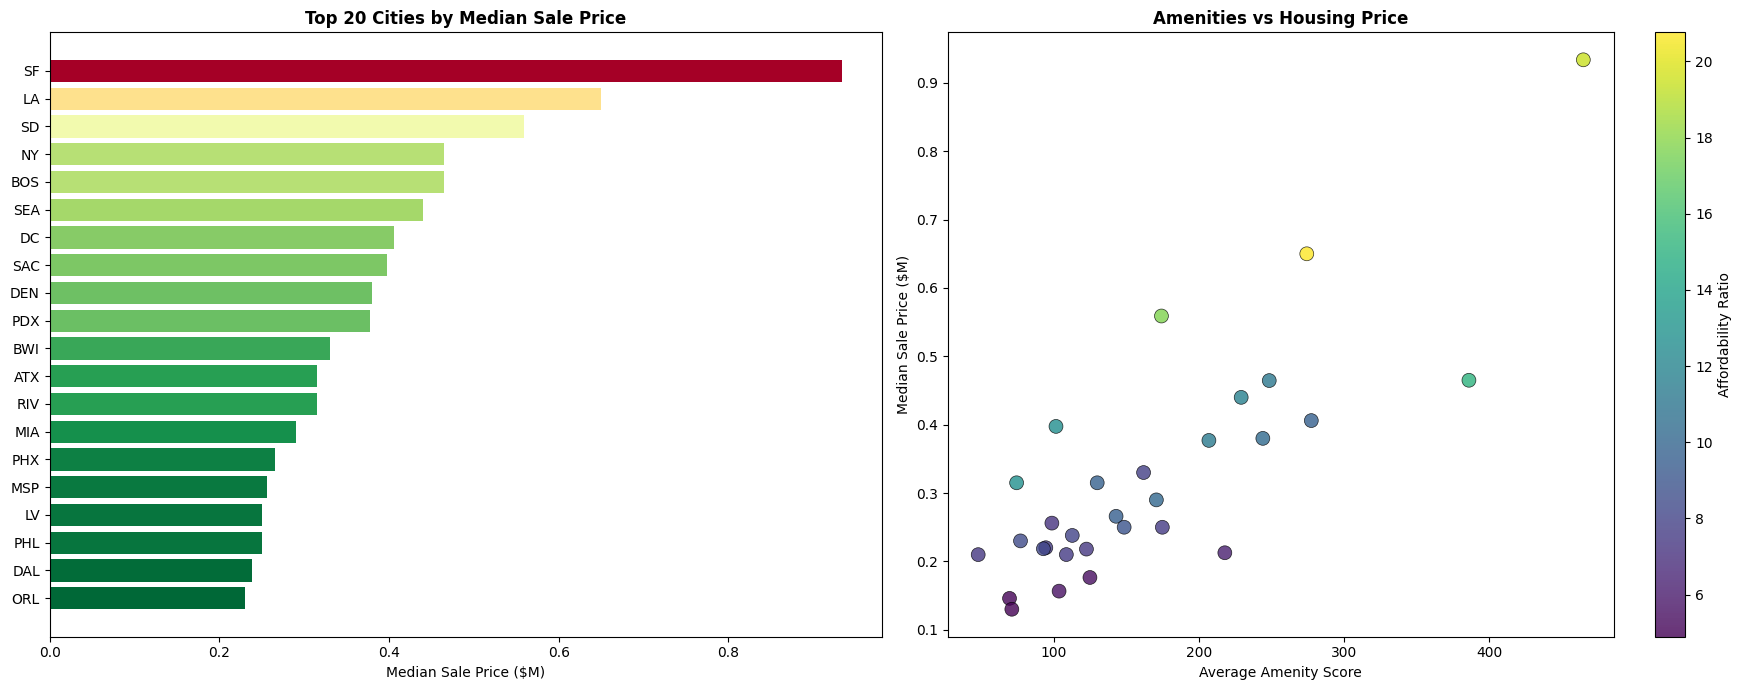

In [18]:
# City-level price aggregates
city_prices = (
    df_clean
    .groupBy("city")
    .agg(
        F.median("median_sale_price").alias("median_price"),
        F.count("*").alias("record_count"),
        F.avg("affordability_ratio").alias("avg_affordability"),
        F.avg("amenity_score").alias("avg_amenities")
    )
    .orderBy(F.desc("median_price"))
    .limit(30)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top20 = city_prices.head(20)
axes[0].barh(top20["city"], top20["median_price"] / 1e6,
             color=plt.cm.RdYlGn_r(
                 (top20["median_price"] - top20["median_price"].min()) /
                 (top20["median_price"].max() - top20["median_price"].min())
             ))
axes[0].set_xlabel("Median Sale Price ($M)")
axes[0].set_title("Top 20 Cities by Median Sale Price", fontweight="bold")
axes[0].invert_yaxis()

scatter = axes[1].scatter(
    city_prices["avg_amenities"], city_prices["median_price"] / 1e6,
    c=city_prices["avg_affordability"], cmap="viridis", s=100, alpha=0.8,
    edgecolors="k", linewidths=0.5
)
plt.colorbar(scatter, ax=axes[1], label="Affordability Ratio")
axes[1].set_xlabel("Average Amenity Score")
axes[1].set_ylabel("Median Sale Price ($M)")
axes[1].set_title("Amenities vs Housing Price", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_city_prices.png", dpi=120, bbox_inches="tight")
plt.show()

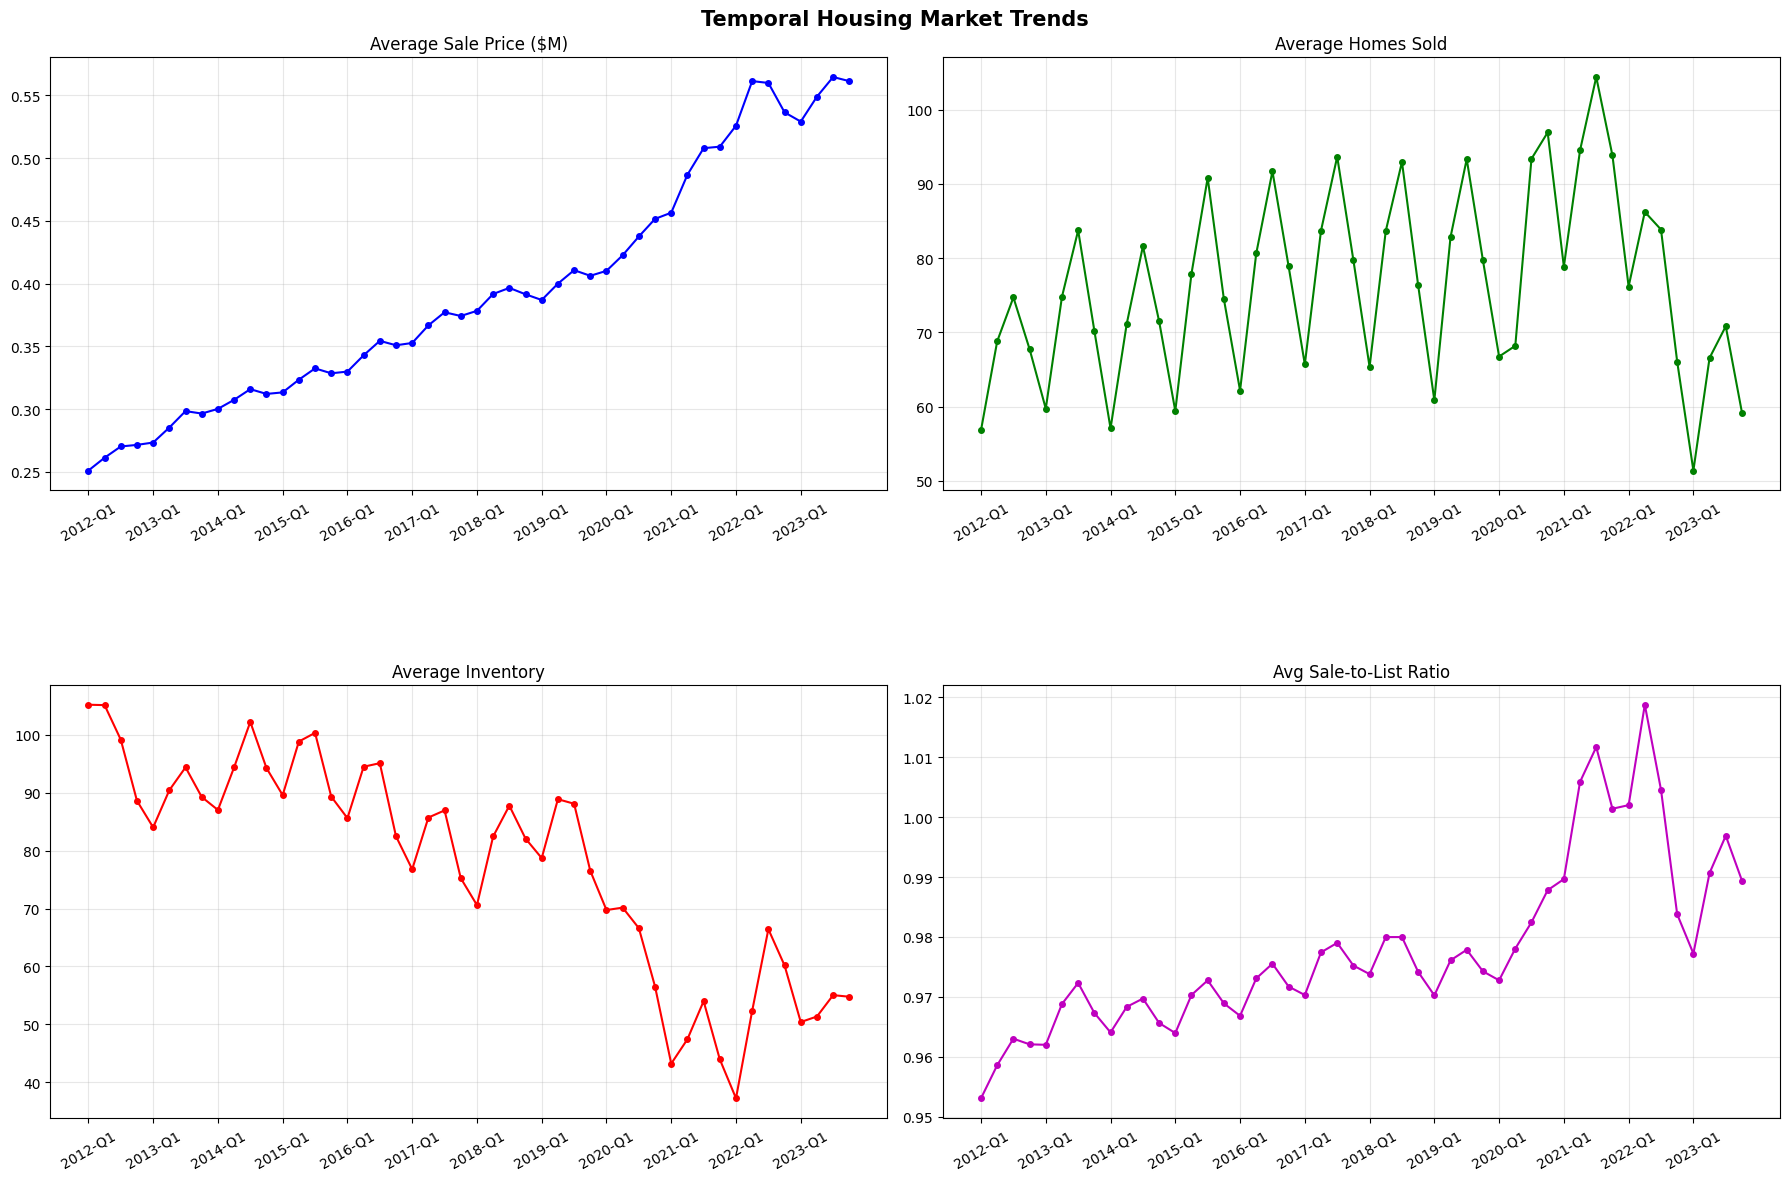

In [19]:
# Temporal trend
temporal = (
    df_clean
    .groupBy("year_parsed", "quarter")
    .agg(
        F.avg("median_sale_price").alias("avg_sale_price"),
        F.avg("homes_sold").alias("avg_homes_sold"),
        F.avg("inventory").alias("avg_inventory"),
        F.avg("avg_sale_to_list").alias("avg_sale_to_list")
    )
    .orderBy("year_parsed", "quarter")
    .toPandas()
)

# Create period label
temporal["period"] = (
    temporal["year_parsed"].astype(str)
    + "-Q"
    + temporal["quarter"].astype(str)
)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Temporal Housing Market Trends", fontsize=15, fontweight="bold")

for ax, col, title, color in zip(
    axes.flat,
    ["avg_sale_price", "avg_homes_sold", "avg_inventory", "avg_sale_to_list"],
    ["Average Sale Price ($M)", "Average Homes Sold", "Average Inventory", "Avg Sale-to-List Ratio"],
    ["b", "g", "r", "m"]
):

    # Convert sale price to millions
    data = temporal[col] / 1e6 if col == "avg_sale_price" else temporal[col]

    ax.plot(temporal["period"], data, f"{color}-o", markersize=4)
    ax.set_title(title)
    ax.set_xticks(range(0, len(temporal["period"]), 4))
    ax.set_xticklabels(temporal["period"][::4], rotation=30)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45)

plt.savefig("eda_temporal_trends.png", dpi=120, bbox_inches="tight")
plt.show()

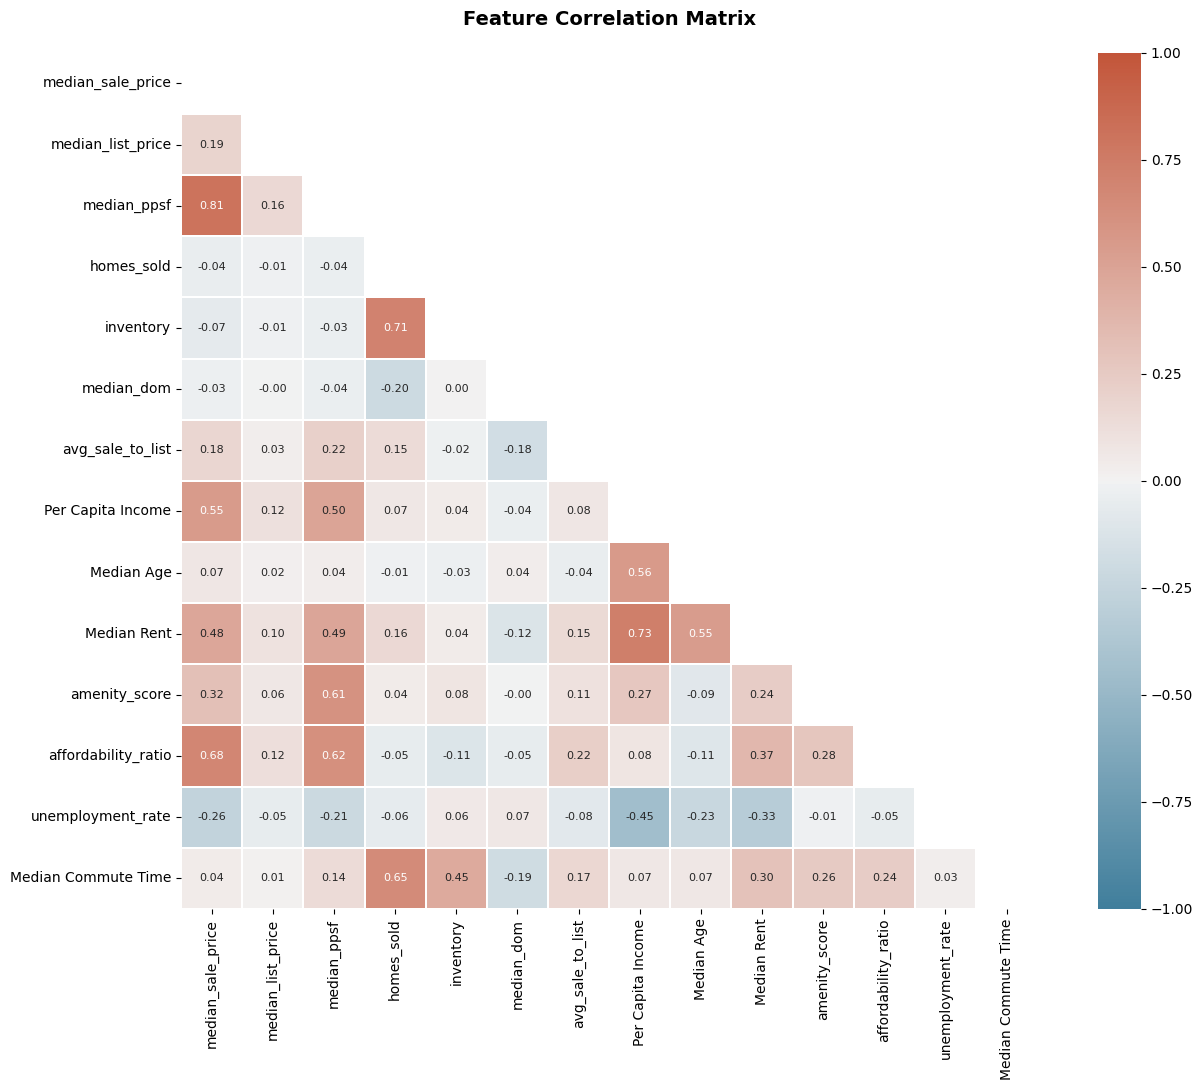

In [20]:
# Correlation heatmap
CORR_COLS = [
    "median_sale_price", "median_list_price", "median_ppsf",
    "homes_sold", "inventory", "median_dom", "avg_sale_to_list",
    "Per Capita Income", "Median Age", "Median Rent", "amenity_score",
    "affordability_ratio", "unemployment_rate", "Median Commute Time"
]
corr_sample = df_clean.select(CORR_COLS).sample(fraction=0.3, seed=RANDOM_SEED).toPandas()
corr_matrix = corr_sample.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=1, vmin=-1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, square=True, linewidths=0.3, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

---
# Stage 3 — Feature Engineering
## 3.1 Image Catalog

In [21]:
pattern = os.path.join(IMAGE_ROOT, "*", "*", "*.png")
all_png_paths = sorted(glob.glob(pattern))

print(f"Glob pattern : {pattern}")
print(f"PNGs found   : {len(all_png_paths):,}")

if len(all_png_paths) == 0:
    alt_pattern = os.path.join(IMAGE_ROOT, "*", "*.png")
    alt_paths   = sorted(glob.glob(alt_pattern))
    print(f"\nTried alternate pattern: {alt_pattern}")
    print(f"PNGs found (2-level)   : {len(alt_paths):,}")
    if len(alt_paths) > 0:
        all_png_paths = alt_paths
        print("Using 2-level pattern.")
    else:
        raise FileNotFoundError(
            f"No PNG files found under {IMAGE_ROOT}.\n"
            f"Tried 3-level: {pattern}\n"
            f"Tried 2-level: {alt_pattern}\n"
            f"Please check IMAGE_ROOT and your folder structure."
        )

# Build metadata rows from path components
manifest_rows = []
for p in all_png_paths:
    parts     = p.split(os.sep)
    filename  = parts[-1]
    zipcode   = parts[-2] if len(parts) >= 2 else "unknown"
    city_dir  = parts[-3] if len(parts) >= 3 else "unknown"
    manifest_rows.append((p, city_dir, zipcode, filename))

from pyspark.sql.types import StructType, StructField, StringType

schema_manifest = StructType([
    StructField("image_path",  StringType(), False),
    StructField("city",        StringType(), True),
    StructField("zipcode_id",  StringType(), True),
    StructField("filename",    StringType(), True),
])

df_images = spark.createDataFrame(manifest_rows, schema=schema_manifest)

if SAMPLE_FRACTION < 1.0:
    df_images = df_images.sample(fraction=SAMPLE_FRACTION, seed=RANDOM_SEED)
    print(f"Sampling {SAMPLE_FRACTION*100:.0f}% of images.")

df_images = df_images.repartition(8).cache()
total_images = df_images.count()
total_cities = df_images.select("city").distinct().count()

print(f"\n Manifest ready: {total_images:,} images across {total_cities} city folders")
df_images.show(5, truncate=False)

sample_path = df_images.select("image_path").first()[0]
try:
    test_img = Image.open(sample_path).convert("RGB")
    print(f" PIL sanity check passed — first image opened: {sample_path}")
    print(f"   Size: {test_img.size}  Mode: {test_img.mode}")
except Exception as e:
    raise RuntimeError(
        f"PIL cannot open the first sampled image.\n"
        f"Path: {sample_path}\nError: {e}\n"
        f"Check file permissions and that the images are valid PNGs."
    )

Glob pattern : /Users/lizamarievaldez/Documents/project/Housets_Image/Housets_Final/*/*/*.png
PNGs found   : 35,099

 Manifest ready: 35,099 images across 30 city folders
+---------------------------------------------------------------------------------------------------+---------+----------+--------------+
|image_path                                                                                         |city     |zipcode_id|filename      |
+---------------------------------------------------------------------------------------------------+---------+----------+--------------+
|/Users/lizamarievaldez/Documents/project/Housets_Image/Housets_Final/Atlanta/30084/30084_2022.png  |Atlanta  |30084     |30084_2022.png|
|/Users/lizamarievaldez/Documents/project/Housets_Image/Housets_Final/Baltimore/21013/21013_2013.png|Baltimore|21013     |21013_2013.png|
|/Users/lizamarievaldez/Documents/project/Housets_Image/Housets_Final/Boston/02367/02367_2012.png   |Boston   |02367     |02367_2012.png|
|

## 3.2 Broadcasted MobileNetV2 Feature Extraction

In [22]:
# DISTRIBUTED FEATURE EXTRACTION

total_images = df_images.count()
print(f"\nTotal images to process: {total_images:,}")
print(f"   Original partitions: {df_images.rdd.getNumPartitions()}")

optimal_partitions = max(16, (total_images // 200))
df_images = df_images.repartition(optimal_partitions)
print(f"   Optimized partitions: {df_images.rdd.getNumPartitions()} (~{total_images//optimal_partitions} images/partition)")

@pandas_udf(ArrayType(FloatType()), PandasUDFType.SCALAR)
def extract_features_udf(image_paths: pd.Series) -> pd.Series:
    """Pandas UDF that extracts features from image paths in parallel.

    The MobileNet extractor class is defined INSIDE this function so it
    gets properly serialized and sent to all executors.
    """
    import torch
    import torch.nn as nn
    import torchvision.models as models
    import torchvision.transforms as transforms
    from PIL import Image
    import numpy as np

    class MobileNetExtractor:
        def __init__(self, img_size=128):
            self.img_size = img_size
            self.device = "cuda" if torch.cuda.is_available() else "cpu"

            # Load MobileNetV2 without classifier
            base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            self.model = nn.Sequential(*list(base.children())[:-1], nn.AdaptiveAvgPool2d(1))
            self.model.eval()
            self.model.to(self.device)

            # Image preprocessing
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

        def extract_single(self, path):
            """Extract features from a single image."""
            try:
                img = Image.open(path).convert("RGB")
                tensor = self.transform(img).unsqueeze(0).to(self.device)

                with torch.no_grad():
                    features = self.model(tensor).squeeze(-1).squeeze(-1).cpu().numpy()

                return features[0]
            except Exception as e:
                return np.zeros(1280, dtype=np.float32)

    # ONE extractor instance per partition (reused for all images in partition)
    extractor = MobileNetExtractor(img_size=IMG_SIZE)

    def process_single_image(path):
        try:
            features = extractor.extract_single(path)
            return features.tolist()
        except Exception as e:
            return np.zeros(1280, dtype=np.float32).tolist()

    return image_paths.apply(process_single_image)

# Apply distributed extraction
print(f"\n Starting DISTRIBUTED feature extraction...")
print(f"   Processing across {spark.sparkContext.defaultParallelism} cores")
print(f"   Each executor will load MobileNetV2 once and reuse it")
print(f"   (This may take 5-15 minutes for 35K images)\n")

df_with_features = df_images.withColumn(
    "raw_features_array",
    extract_features_udf(F.col("image_path"))
)

# Convert to vectors
from pyspark.ml.linalg import Vectors, VectorUDT

def array_to_vector_udf(arr):
    """Convert array to DenseVector, filter zeros."""
    if arr and sum(arr) != 0:
        return Vectors.dense(arr)
    else:
        return None

array_to_vector = F.udf(array_to_vector_udf, VectorUDT())

df_with_vectors = (
    df_with_features
    .withColumn("raw_features", array_to_vector(F.col("raw_features_array")))
    .select("city", "zipcode_id", "image_path", "raw_features")
)

# Filter nulls and cache
df_embeddings_valid = df_with_vectors.filter(F.col("raw_features").isNotNull()).cache()

# Verify results
print(" Executing distributed processing...")
n_valid = df_embeddings_valid.count()
n_skipped = total_images - n_valid

print(f"\n DISTRIBUTED feature extraction complete!")
print(f"   Images attempted     : {total_images:,}")
print(f"   Embeddings produced  : {n_valid:,}")
print(f"   Skipped/corrupted    : {n_skipped:,}")
print(f"   Success rate         : {n_valid/total_images*100:.1f}%")
print(f"   Embedding dimensions : 1280")
print(f"   Processing mode      : DISTRIBUTED\n")

# Validation
if n_valid == 0:
    raise RuntimeError(
        f" FATAL: No valid embeddings from {total_images:,} images.\n"
        "Check image paths and PyTorch installation."
    )

if n_valid < 100:
    print(f"  WARNING: Only {n_valid} embeddings. Quality may be poor.")

df_embeddings_valid.show(3, truncate=True)


Total images to process: 35,099
   Original partitions: 8
   Optimized partitions: 175 (~200 images/partition)

 Starting DISTRIBUTED feature extraction...
   Processing across 8 cores
   Each executor will load MobileNetV2 once and reuse it
   (This may take 5-15 minutes for 35K images)

 Executing distributed processing...

 DISTRIBUTED feature extraction complete!
   Images attempted     : 35,099
   Embeddings produced  : 35,099
   Skipped/corrupted    : 0
   Success rate         : 100.0%
   Embedding dimensions : 1280
   Processing mode      : DISTRIBUTED

+------------+----------+--------------------+--------------------+
|        city|zipcode_id|          image_path|        raw_features|
+------------+----------+--------------------+--------------------+
| Los_Angeles|     90007|/Users/lizamariev...|[0.28801876306533...|
|   Baltimore|     21218|/Users/lizamariev...|[0.01380928792059...|
|Philadelphia|     19460|/Users/lizamariev...|[0.18220077455043...|
+------------+----------

In [23]:
# Prepare embeddings DataFrame for fusion

# Rename for compatibility with downstream cells
df_embeddings = df_embeddings_valid.select(
    F.col("city"),
    F.col("zipcode_id"),
    F.col("raw_features")
).repartition(8).cache()

print(f"Embedding DataFrame prepared: {df_embeddings.count():,} rows")
df_embeddings.show(3, truncate=True)

# StandardScaler for image features
scaler       = StandardScaler(inputCol="raw_features", outputCol="scaled_features",
                              withStd=True, withMean=True)
scaler_model = scaler.fit(df_embeddings)
df_scaled    = scaler_model.transform(df_embeddings)
print("✓ Image features standardized")


Embedding DataFrame prepared: 35,099 rows
+-----------+----------+--------------------+
|       city|zipcode_id|        raw_features|
+-----------+----------+--------------------+
|San_Antonio|     78230|[0.31885772943496...|
|    Houston|     77306|[0.31982606649398...|
|    Phoenix|     85395|[0.27051407098770...|
+-----------+----------+--------------------+
only showing top 3 rows

✓ Image features standardized


## 3.4 Join Image Features with Tabular Data

In [24]:
from itertools import chain

CSV_ABBREV_TO_FOLDER = {
    "ATL": "Atlanta",
    "BOS": "Boston",
    "CHI": "Chicago",
    "DEN": "Denver",
    "LA":  "Los_Angeles",
    "MIA": "Miami",
    "MSP": "Minneapolis",
    "NY":  "New_York",
    "ORL": "Orlando",
    "PHX": "Phoenix",
    "PHL": "Philadelphia",
    "PGH": "Pittsburgh",
    "RIV": "Riverside",
    "STL": "St._Louis",
    "SF":  "San_Francisco",
    "SD":  "San_Diego",
    "TPA": "Tampa",
    "ATX": "Austin",
    "DC":  "DC",
    "DAL": "Dallas",
    "CLT": "Charlotte",
    "DET": "Detroit",
    "HOU": "Houston",
    "SAC": "Sacramento",
    "BWI": "Baltimore",
    "CIN": "Cincinnati",
    "LV":  "Las_Vegas",
    "PDX": "Portland",
    "SA":  "San_Antonio",
    "SEA": "Seattle",
}

mapping_expr = F.create_map([F.lit(x) for x in chain(*CSV_ABBREV_TO_FOLDER.items())])

# Translate CSV city abbreviations
df_clean_mapped = df_clean.withColumn(
    "city_folder",
    F.coalesce(mapping_expr[F.trim(F.col("city"))], F.col("city"))
)

# Verify translation quality
print("Sample of abbreviation → folder mapping:")
df_clean_mapped.select("city", "city_folder").distinct().orderBy("city").show(30, truncate=False)

image_cities  = set(r["city"] for r in df_images.select("city").distinct().collect())
mapped_cities = set(r["city_folder"] for r in
                    df_clean_mapped.select("city_folder").distinct().collect())
matched = image_cities & mapped_cities
unmatched_img = image_cities - mapped_cities
unmatched_csv = mapped_cities - image_cities

print(f"\nImage folders found on disk : {sorted(image_cities)}")
print(f"Matched cities              : {len(matched)} — {sorted(matched)}")
if unmatched_img:
    print(f"⚠ Image folders with no CSV match : {sorted(unmatched_img)}")
    print(f"  → Add these to CSV_ABBREV_TO_FOLDER if you want their tabular data included.")
if unmatched_csv:
    print(f"⚠ CSV cities with no image folder : {sorted(list(unmatched_csv)[:10])}")

Sample of abbreviation → folder mapping:
+----+-------------+
|city|city_folder  |
+----+-------------+
|ATL |Atlanta      |
|ATX |Austin       |
|BOS |Boston       |
|BWI |Baltimore    |
|CHI |Chicago      |
|CIN |Cincinnati   |
|CLT |Charlotte    |
|DAL |Dallas       |
|DC  |DC           |
|DEN |Denver       |
|DET |Detroit      |
|HOU |Houston      |
|LA  |Los_Angeles  |
|LV  |Las_Vegas    |
|MIA |Miami        |
|MSP |Minneapolis  |
|NY  |New_York     |
|ORL |Orlando      |
|PDX |Portland     |
|PGH |Pittsburgh   |
|PHL |Philadelphia |
|PHX |Phoenix      |
|RIV |Riverside    |
|SA  |San_Antonio  |
|SAC |Sacramento   |
|SD  |San_Diego    |
|SEA |Seattle      |
|SF  |San_Francisco|
|STL |St._Louis    |
|TPA |Tampa        |
+----+-------------+


Image folders found on disk : ['Atlanta', 'Austin', 'Baltimore', 'Boston', 'Charlotte', 'Chicago', 'Cincinnati', 'DC', 'Dallas', 'Denver', 'Detroit', 'Houston', 'Las_Vegas', 'Los_Angeles', 'Miami', 'Minneapolis', 'New_York', 'Orlando', 'Philad

In [25]:
# Compute per-city tabular statistics, based on the folder name

city_stats = (
    df_clean_mapped
    .groupBy("city_folder")
    .agg(
        F.avg("median_sale_price").alias("avg_sale_price"),
        F.avg("Per Capita Income").alias("avg_income"),
        F.avg("amenity_score").alias("avg_amenity"),
        F.avg("unemployment_rate").alias("avg_unemployment"),
        F.avg("affordability_ratio").alias("avg_affordability"),
        F.avg("price_to_rent_ratio").alias("avg_ptr"),
        F.avg("Median Age").alias("avg_median_age"),
        F.avg("Median Commute Time").alias("avg_commute")
    )
)

df_final = (
    df_scaled.select("city", "zipcode_id", "scaled_features")
    .join(city_stats, df_scaled["city"] == city_stats["city_folder"], how="left")
    .drop("city_folder")
)

total_rows  = df_final.count()
null_rows   = df_final.filter(F.col("avg_sale_price").isNull()).count()
join_rate   = (total_rows - null_rows) / total_rows * 100

print(f"Join result: {total_rows:,} rows | {null_rows:,} with null tabular cols ({100-join_rate:.1f}%)")

if join_rate < 50:
    print(
        "⚠ WARNING: More than half of image rows have no matching tabular data.\n"
        "  Check CSV_ABBREV_TO_FOLDER — likely some city abbreviations are missing.\n"
        "  The clustering will still work but without tabular enrichment for those cities."
    )

df_final = df_final.repartition(8).cache()
df_final.select("city", "zipcode_id", "avg_sale_price", "avg_income").show(10, truncate=False)

Join result: 35,099 rows | 0 with null tabular cols (0.0%)
+---------+----------+------------------+------------------+
|city     |zipcode_id|avg_sale_price    |avg_income        |
+---------+----------+------------------+------------------+
|Dallas   |76234     |267453.59101621684|33214.784411649176|
|Houston  |77502     |238033.2668660364 |32525.07389542736 |
|Denver   |80128     |402814.4263661972 |40003.48          |
|Austin   |78733     |364983.4241729446 |38045.16229937766 |
|Miami    |33428     |350264.7760291028 |35468.30923663528 |
|Riverside|92264     |337082.47583445883|27075.62704997106 |
|Chicago  |60102     |238416.21015320648|37455.153880731195|
|Atlanta  |30121     |241522.15579685007|31873.386942343717|
|Detroit  |48001     |190829.45796138333|33296.96435892349 |
|Boston   |02420     |552657.324189623  |49050.72188276719 |
+---------+----------+------------------+------------------+
only showing top 10 rows



---
# Stage 3.5 — Multimodal Feature Fusion: Geography × Wealth Latent Space

## Overview

We combine **image-derived features** (capturing spatial/geographic appearance) with **tabular socioeconomic indicators** (representing wealth/economic conditions) into a unified 2D latent space. This multimodal fusion enables K-Means clustering to group neighborhoods by **both visual characteristics AND economic profile**.

## Architecture: Two-Branch Feature Fusion

```
┌──────────────────────────────────────────────────────────────────┐
│                    BRANCH A: GEOGRAPHY AXIS                       │
│         MobileNetV2 → Scaled Features (NO PCA)                   │
│             (1280D)        (1280D)                                │
└──────────────────────────────────────────────────────────────────┘
                              ↓
                        CONCATENATE
                              ↓
┌──────────────────────────────────────────────────────────────────┐
│                     BRANCH B: WEALTH AXIS                         │
│  Tabular Features → Scaled → PCA → Wealth Latent Vector          │
│     (8 features)    (8D)    (8D)         (8D)                    │
└──────────────────────────────────────────────────────────────────┘
                              ↓
                    FUSED REPRESENTATION
                          (1288D)
                              ↓
                      Scale & Final PCA
                              ↓
                  GEOGRAPHY × WEALTH PLANE (2D)
```

## Mathematical Formulation

### Branch A: Image Features (Geography Axis)

For each neighborhood image $i$, MobileNetV2 extracts a feature vector:

$$\mathbf{x}_i^{\text{img}} \in \mathbb{R}^{1280}$$

**Standardization (Only Step):**

$$\mathbf{z}_i^{\text{geo}} = \mathbf{x}_i^{\text{scaled}} = \frac{\mathbf{x}_i^{\text{img}} - \boldsymbol{\mu}_{\text{img}}}{\boldsymbol{\sigma}_{\text{img}}} \in \mathbb{R}^{1280}$$

where $\boldsymbol{\mu}_{\text{img}}$ and $\boldsymbol{\sigma}_{\text{img}}$ are the mean and standard deviation computed across all neighborhood images.

**Note:** Per professor's recommendation, we do NOT apply PCA to image features. We use the full 1280-dimensional MobileNetV2 embeddings directly. This preserves all learned visual patterns from the pre-trained network.

### Branch B: Tabular Features (Wealth Axis)

For each city $c$, we aggregate 8 socioeconomic indicators:

$$\mathbf{t}_c = \begin{bmatrix}
\text{avg\_sale\_price} \\
\text{avg\_income} \\
\text{avg\_amenity} \\
\text{avg\_unemployment} \\
\text{avg\_affordability} \\
\text{avg\_ptr} \\
\text{avg\_median\_age} \\
\text{avg\_commute}
\end{bmatrix} \in \mathbb{R}^8$$

**Step 1: Standardization**

$$\mathbf{t}_c^{\text{scaled}} = \frac{\mathbf{t}_c - \boldsymbol{\mu}_{\text{tab}}}{\boldsymbol{\sigma}_{\text{tab}}}$$

**Step 2: PCA (Wealth)**

$$\mathbf{z}_c^{\text{wealth}} = \mathbf{W}_{\text{wealth}}^T \mathbf{t}_c^{\text{scaled}} \in \mathbb{R}^{8}$$

where $\mathbf{W}_{\text{wealth}} \in \mathbb{R}^{8 \times 8}$ captures the principal components of tabular data.

### Fusion: Concatenation

For each neighborhood $i$ in city $c$, we concatenate both representations:

$$\mathbf{f}_i = \begin{bmatrix} \mathbf{z}_i^{\text{geo}} \\ \mathbf{z}_c^{\text{wealth}} \end{bmatrix} = \begin{bmatrix} \mathbf{z}_i^{\text{geo}, 1} \\ \vdots \\ \mathbf{z}_i^{\text{geo}, 1280} \\ \mathbf{z}_c^{\text{wealth}, 1} \\ \vdots \\ \mathbf{z}_c^{\text{wealth}, 8} \end{bmatrix} \in \mathbb{R}^{1288}$$

This creates a **fused multimodal representation** where:
- **Dimensions 1-1280** capture **geographic/visual patterns** from MobileNetV2 (building density, architecture, street layouts, vegetation, urban form)
- **Dimensions 1281-1288** capture **economic conditions** (housing prices, income levels, unemployment, affordability)

### Final 2D Projection

**Step 1: Standardize fused features**

$$\mathbf{f}_i^{\text{scaled}} = \frac{\mathbf{f}_i - \boldsymbol{\mu}_{\text{fused}}}{\boldsymbol{\sigma}_{\text{fused}}}$$

**Step 2: Final PCA to 2D latent space**

$$\mathbf{L}_i = \mathbf{W}_{\text{final}}^T \mathbf{f}_i^{\text{scaled}} = \begin{bmatrix} L_i^{\text{geo}} \\ L_i^{\text{wealth}} \end{bmatrix} \in \mathbb{R}^{2}$$

where $\mathbf{W}_{\text{final}} \in \mathbb{R}^{1288 \times 2}$ are the top 2 principal components that automatically determine the optimal weighting between visual and economic features, and:
- $L_i^{\text{geo}}$ (PC1) represents the **primary axis of variation** (typically geographic)
- $L_i^{\text{wealth}}$ (PC2) represents the **secondary axis of variation** (typically wealth-related)

This 2D latent space $\mathbf{L} = \{\mathbf{L}_1, \mathbf{L}_2, \ldots, \mathbf{L}_N\}$ enables:
1. **Visualization** of the joint distribution of neighborhoods across geography and wealth
2. **K-Means clustering** to identify groups with similar geographic appearance AND economic profile

## Complete Data Flow

The complete transformation from raw data to 2D latent space:

$$\text{Images} \xrightarrow{\text{MobileNetV2}} \mathbf{x}^{\text{img}}_{1280} \xrightarrow{\text{Scale}} \mathbf{z}^{\text{geo}}_{1280}$$

$$\text{Tabular} \xrightarrow{\text{Aggregate}} \mathbf{t}_8 \xrightarrow{\text{Scale}} \mathbf{t}^{\text{scaled}}_8 \xrightarrow{\text{PCA}} \mathbf{z}^{\text{wealth}}_8$$

$$\mathbf{z}^{\text{geo}}_{1280} \oplus \mathbf{z}^{\text{wealth}}_8 \xrightarrow{\text{Concat}} \mathbf{f}_{1288} \xrightarrow{\text{Scale}} \mathbf{f}^{\text{scaled}}_{1288} \xrightarrow{\text{PCA}} \mathbf{L}_2$$

where $\oplus$ denotes vector concatenation.

## Why This Fusion Strategy?

1. **Complementary Information**:
   - Images capture **physical characteristics** (urban density, architectural style, greenery, street patterns)
   - Tabular data captures **economic outcomes** (prices, income, employment, affordability)
   - Together they provide a complete picture of neighborhood character

2. **Preserve Pre-trained Knowledge**:
   - MobileNetV2 was trained on millions of images - its 1280 features encode rich visual patterns
   - By NOT applying PCA to image features, we preserve all this learned information
   - The final PCA step learns which dimensions (visual or economic) matter most for this specific clustering task

3. **Automatic Weighting**:
   - StandardScaler ensures fair comparison across all 1288 dimensions
   - Final PCA automatically determines optimal balance between image and tabular features
   - No manual tuning of dimension ratios needed

4. **Interpretability**:
   - Final 2D space separates the two primary axes of variation
   - Clusters become interpretable along both geographic and economic dimensions
   - Easy to visualize and communicate results

5. **Clustering Quality**:
   - K-Means on fused space groups neighborhoods similar in **both appearance AND economics**
   - Avoids clusters based solely on visual similarity or solely on economics
   - Results in more actionable, holistic neighborhood typologies

---


---
# Stage 3.5 — Multimodal Feature Fusion: Geography × Wealth Latent Space

Combines **image-derived PCA features** (spatial / geographic appearance) with
**tabular socioeconomic indicators** (wealth / economic conditions) into a single
unified 2D latent space via a two-branch architecture:

- **Branch A — Geography** : MobileNetV2 → PCA(64) → StandardScaler → SparkPCA(16) → 1st latent axis
- **Branch B — Wealth** : Tabular socioeconomic features → StandardScaler → SparkPCA(16) → 2nd latent axis
- **Fusion** : Concatenate both branches → joint StandardScaler → SparkPCA(2) = *Geography × Wealth plane*

Downstream K-Means clustering operates on this fused 2D representation so that
every cluster groups regions by **both spatial appearance AND socioeconomic profile**.


In [26]:
# Stage 3.5-A  Tabular Socioeconomic Branch  (Wealth Axis)

TAB_FEATURES = [
    "avg_sale_price", "avg_income", "avg_amenity",
    "avg_unemployment", "avg_affordability", "avg_ptr",
    "avg_median_age", "avg_commute",
]

# Impute nulls in tabular cols with column median
tab_medians = {
    c: df_final.approxQuantile(c, [0.5], 0.05)[0]
    for c in TAB_FEATURES if c in df_final.columns
}
df_fused_base = df_final
for col_name, med_val in tab_medians.items():
    if med_val is not None:
        df_fused_base = df_fused_base.withColumn(
            col_name,
            F.when(F.col(col_name).isNull(), float(med_val)).otherwise(F.col(col_name))
        )

# Drop rows still missing pca_features
df_fused_base = df_fused_base.dropna(subset=["scaled_features"]).cache()
print(f"Tabular imputation complete | Rows for fusion: {df_fused_base.count():,}")

# Assemble tabular features into a Spark vector
present_tab_features = [c for c in TAB_FEATURES if c in df_fused_base.columns]

tab_assembler = VectorAssembler(
    inputCols=present_tab_features,
    outputCol="tab_raw_vec",
    handleInvalid="skip"
)
df_tab_vec = tab_assembler.transform(df_fused_base)

# Scale tabular branch
tab_scaler = StandardScaler(inputCol="tab_raw_vec", outputCol="tab_scaled",
                            withStd=True, withMean=True)
tab_scaler_model = tab_scaler.fit(df_tab_vec)
df_tab_scaled = tab_scaler_model.transform(df_tab_vec)

# PCA on tabular branch: compress to N_TAB_PCA latent dims
N_TAB_PCA = min(8, len(present_tab_features))
tab_pca_spark = SparkPCA(k=N_TAB_PCA, inputCol="tab_scaled", outputCol="tab_pca")
tab_pca_model = tab_pca_spark.fit(df_tab_scaled)
df_tab_pca = tab_pca_model.transform(df_tab_scaled)

tab_var_retained = float(np.cumsum(tab_pca_model.explainedVariance.toArray())[N_TAB_PCA - 1]) * 100
print(f"   Tabular PCA: {len(present_tab_features)} features -> {N_TAB_PCA} dims "
      f"({tab_var_retained:.1f}% variance retained)")

df_tab_pca.select("city", "zipcode_id", "tab_pca").show(3, truncate=True)


Tabular imputation complete | Rows for fusion: 35,099
   Tabular PCA: 8 features -> 8 dims (100.0% variance retained)
+-------+----------+--------------------+
|   city|zipcode_id|             tab_pca|
+-------+----------+--------------------+
| Dallas|     76234|[0.82729754079728...|
|Houston|     77502|[1.07121623019733...|
| Denver|     80128|[-0.7832279325564...|
+-------+----------+--------------------+
only showing top 3 rows



In [27]:
# Fuse Image + Tabular -> Geography x Wealth 2D Latent Space
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np

print(f"   Image branch: Using full 1280-dimensional scaled features (no PCA)")

df_img_latent = df_tab_pca.withColumnRenamed("scaled_features", "img_latent")

# Concatenate both latent vectors into one fusion vector
@F.udf(VectorUDT())
def concat_vectors(v1, v2):
    if v1 is None or v2 is None:
        return None
    import numpy as _np
    arr = _np.concatenate([_np.array(v1), _np.array(v2)], axis=0)
    return Vectors.dense(arr.tolist())

df_fused_vec = (
    df_img_latent
    .withColumn("fused_raw", concat_vectors(F.col("img_latent"), F.col("tab_pca")))
    .dropna(subset=["fused_raw"])
)

N_IMG_DIMS = 1280  # Full MobileNetV2 features
N_TAB_DIMS = min(8, len(present_tab_features))
total_fused_dims = N_IMG_DIMS + N_TAB_DIMS

print(f"\nFusion complete: {N_IMG_DIMS}(geo) + {N_TAB_DIMS}(wealth) = {total_fused_dims}-dim fused vector")
print(f"   Rows in fused DataFrame: {df_fused_vec.count():,}")

# Scale fused vector
fused_scaler = StandardScaler(inputCol="fused_raw", outputCol="fused_scaled",
                              withStd=True, withMean=True)
fused_scaler_model = fused_scaler.fit(df_fused_vec)
df_fused_scaled = fused_scaler_model.transform(df_fused_vec)

# Final PCA: fused -> 2D (the Geography x Wealth plane)
fused_pca = SparkPCA(k=2, inputCol="fused_scaled", outputCol="latent_2d")
fused_pca_model = fused_pca.fit(df_fused_scaled)
df_latent_2d = fused_pca_model.transform(df_fused_scaled)

latent_var = np.cumsum(fused_pca_model.explainedVariance.toArray())
print(f"\n   2D Latent Space variance: PC1={latent_var[0]*100:.1f}%  "
      f"PC2={latent_var[1]*100:.1f}%  total={latent_var[1]*100:.1f}%")

# Extract the raw 2 floats for clustering and plotting
@F.udf(FloatType())
def vec_get_0(v): return float(v[0]) if v is not None else None

@F.udf(FloatType())
def vec_get_1(v): return float(v[1]) if v is not None else None

df_latent_2d = (
    df_latent_2d
    .withColumn("geo_axis",    vec_get_0(F.col("latent_2d")))
    .withColumn("wealth_axis", vec_get_1(F.col("latent_2d")))
    .cache()
)

print("\nSample of 2D latent coordinates:")
df_latent_2d.select("city", "geo_axis", "wealth_axis").show(8, truncate=False)


   Image branch: Using full 1280-dimensional scaled features (no PCA)

Fusion complete: 1280(geo) + 8(wealth) = 1288-dim fused vector
   Rows in fused DataFrame: 35,099

   2D Latent Space variance: PC1=8.0%  PC2=13.9%  total=13.9%

Sample of 2D latent coordinates:
+---------+----------+-----------+
|city     |geo_axis  |wealth_axis|
+---------+----------+-----------+
|Dallas   |16.620539 |10.371365  |
|Houston  |-12.088492|5.9412327  |
|Denver   |6.712954  |3.3203385  |
|Austin   |-4.395655 |-19.768553 |
|Miami    |-14.275786|13.9476185 |
|Riverside|15.680038 |14.803259  |
|Chicago  |4.7880754 |10.155038  |
|Atlanta  |17.167587 |-2.9382594 |
+---------+----------+-----------+
only showing top 8 rows



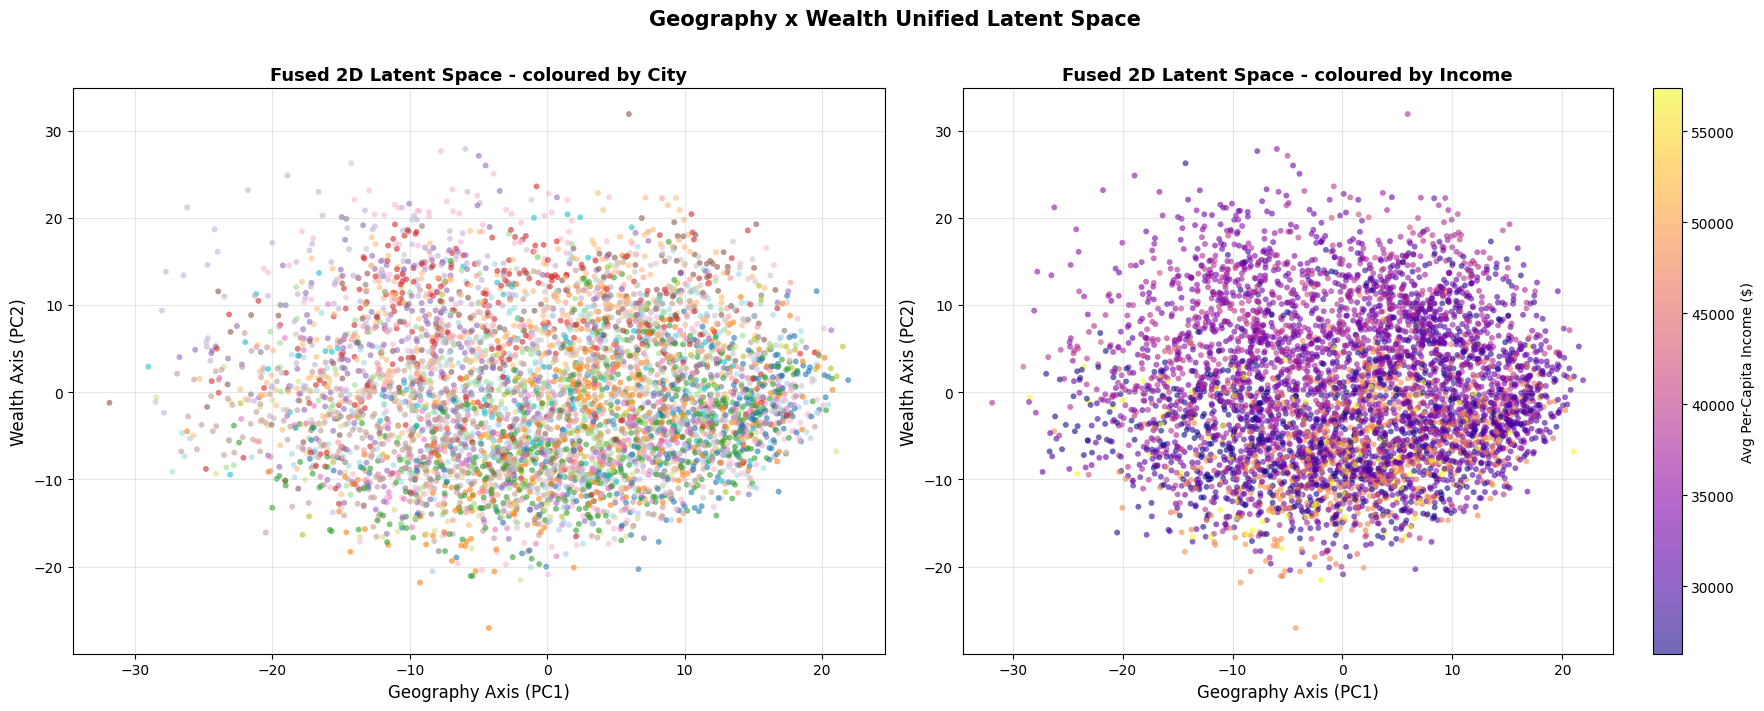

Latent space visualisation saved -> latent_space_2d.png


In [28]:
# Stage 3.5-C  Visualise the Geography x Wealth Latent Space (before clustering)

latent_vis = (
    df_latent_2d
    .select("city", "geo_axis", "wealth_axis", "avg_income", "avg_sale_price")
    .sample(fraction=min(1.0, 5000 / df_latent_2d.count()), seed=RANDOM_SEED)
    .toPandas()
    .dropna(subset=["geo_axis", "wealth_axis"])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

city_codes = latent_vis["city"].astype("category").cat.codes
sc1 = axes[0].scatter(latent_vis["geo_axis"], latent_vis["wealth_axis"],
                      c=city_codes, cmap="tab20", alpha=0.6, s=18, edgecolors="none")
axes[0].set_xlabel("Geography Axis (PC1)", fontsize=12)
axes[0].set_ylabel("Wealth Axis (PC2)", fontsize=12)
axes[0].set_title("Fused 2D Latent Space - coloured by City", fontsize=13, fontweight="bold")
axes[0].grid(alpha=0.3)

income_vals = latent_vis["avg_income"].fillna(latent_vis["avg_income"].median())
sc2 = axes[1].scatter(latent_vis["geo_axis"], latent_vis["wealth_axis"],
                      c=income_vals, cmap="plasma", alpha=0.6, s=18, edgecolors="none")
plt.colorbar(sc2, ax=axes[1], label="Avg Per-Capita Income ($)")
axes[1].set_xlabel("Geography Axis (PC1)", fontsize=12)
axes[1].set_ylabel("Wealth Axis (PC2)", fontsize=12)
axes[1].set_title("Fused 2D Latent Space - coloured by Income", fontsize=13, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.suptitle("Geography x Wealth Unified Latent Space", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("latent_space_2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Latent space visualisation saved -> latent_space_2d.png")


---
# Stage 4 - K-Means Clustering on Geography x Wealth Latent Space
## 4.1 Top-K Evaluation: Silhouette · Balance · Interpretability · Centroids

In [29]:
# Top-K Evaluation on Geography x Wealth Fused Latent Space
from sklearn.metrics import silhouette_score as sk_silhouette
import warnings; warnings.filterwarnings("ignore")

_all_tab_cols = [
    "avg_sale_price", "avg_income", "avg_amenity",
    "avg_unemployment", "avg_affordability",
    "avg_ptr", "avg_median_age", "avg_commute",
]
_present_tab_cols = [c for c in _all_tab_cols if c in df_latent_2d.columns]

df_for_cluster = (
    df_latent_2d
    .dropna(subset=["latent_2d"])
    .select(
        "city", "zipcode_id", "latent_2d",
        "geo_axis", "wealth_axis",
        *_present_tab_cols
    )
    .cache()
)
n_cluster_rows = df_for_cluster.count()
print(f"Rows for clustering (latent_2d): {n_cluster_rows:,}")

if n_cluster_rows < 10:
    raise RuntimeError(
        f"Only {n_cluster_rows} rows - cannot cluster. "
        "Check that Stage 3.5 fusion succeeded."
    )

MAX_K   = min(12, n_cluster_rows // 2)
k_range = range(2, MAX_K + 1)

evaluator_latent = ClusteringEvaluator(
    featuresCol="latent_2d",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

records = []

print(f"{'K':>3}  {'WCSSE':>12}  {'Sil(Spark)':>10}  {'Sil(sklearn)':>12}  "
      f"{'CV_Balance':>11}  {'Interp':>8}")
print("-" * 65)

for k in k_range:
    km = KMeans(
        featuresCol="latent_2d", predictionCol="cluster",
        k=k, maxIter=60, seed=RANDOM_SEED, initMode="k-means||", initSteps=5
    )
    km_model  = km.fit(df_for_cluster)
    df_pred_k = km_model.transform(df_for_cluster)

    wcsse  = km_model.summary.trainingCost
    sil_sp = evaluator_latent.evaluate(df_pred_k)

    # Cluster size balance: CV = std / mean of cluster sizes (lower = better)
    sizes = [r["count"] for r in
             df_pred_k.groupBy("cluster").count().collect()]
    sizes_arr = np.array(sizes, dtype=float)
    cv_balance = float(np.std(sizes_arr) / np.mean(sizes_arr))

    # Interpretability
    profile_cols = ["avg_sale_price", "avg_income", "avg_amenity",
                    "avg_unemployment", "avg_affordability"]
    present_profile = [c for c in profile_cols if c in df_pred_k.columns]

    centroid_profiles = (
        df_pred_k
        .groupBy("cluster")
        .agg(*[F.avg(c).alias(c) for c in present_profile])
        .orderBy("cluster")
        .toPandas()
    )
    prof_vals = centroid_profiles[present_profile].values
    col_stds  = prof_vals.std(axis=0) + 1e-9
    prof_norm = prof_vals / col_stds
    dists = []
    for i in range(len(prof_norm)):
        for j in range(i + 1, len(prof_norm)):
            dists.append(np.linalg.norm(prof_norm[i] - prof_norm[j]))
    interp_score = float(np.mean(dists)) if dists else 0.0

    # sklearn silhouette on sampled 2D latent coords
    sample_size = min(2000, n_cluster_rows)
    sample_frac = sample_size / n_cluster_rows
    lat_sample  = (
        df_pred_k
        .select("geo_axis", "wealth_axis", "cluster")
        .sample(fraction=sample_frac, seed=RANDOM_SEED)
        .toPandas()
        .dropna()
    )
    if len(lat_sample) >= 2 * k:
        sil_sk = float(sk_silhouette(
            lat_sample[["geo_axis", "wealth_axis"]].values,
            lat_sample["cluster"].values
        ))
    else:
        sil_sk = float("nan")

    records.append({
        "K":                  k,
        "WCSSE":              wcsse,
        "Silhouette_Spark":   sil_sp,
        "Silhouette_sklearn": sil_sk,
        "CV_Balance":         cv_balance,
        "Interp_Score":       interp_score,
        "cluster_sizes":      sizes,
        "centroid_profiles":  centroid_profiles,
        "model":              km_model,
    })

    print(f"{k:>3}  {wcsse:>12.3e}  {sil_sp:>10.4f}  {sil_sk:>12.4f}  "
          f"{cv_balance:>11.4f}  {interp_score:>8.4f}")

silhouettes = [r["Silhouette_Spark"] for r in records]
inertias    = [r["WCSSE"] for r in records]

print("\nTop-K evaluation loop complete")


Rows for clustering (latent_2d): 35,099
  K         WCSSE  Sil(Spark)  Sil(sklearn)   CV_Balance    Interp
-----------------------------------------------------------------
  2     3.734e+06      0.5317        0.3713       0.0613    4.4721
  3     2.515e+06      0.5437        0.3707       0.1764    3.7818
  4     1.870e+06      0.5279        0.3567       0.1412    3.5462
  5     1.485e+06      0.5197        0.3522       0.1851    3.3985
  6     1.267e+06      0.5260        0.3612       0.1930    3.2780
  7     1.078e+06      0.5154        0.3618       0.1566    3.2184
  8     9.703e+05      0.4931        0.3371       0.1682    3.1690
  9     8.794e+05      0.4849        0.3238       0.2032    3.1298
 10     7.903e+05      0.4917        0.3341       0.1908    3.1011
 11     7.268e+05      0.4895        0.3277       0.2017    3.0695
 12     6.745e+05      0.4797        0.3205       0.2016    3.0531

Top-K evaluation loop complete


Best K (composite: 0.40 Sil_sk + 0.35 Balance + 0.25 Interp) = 2


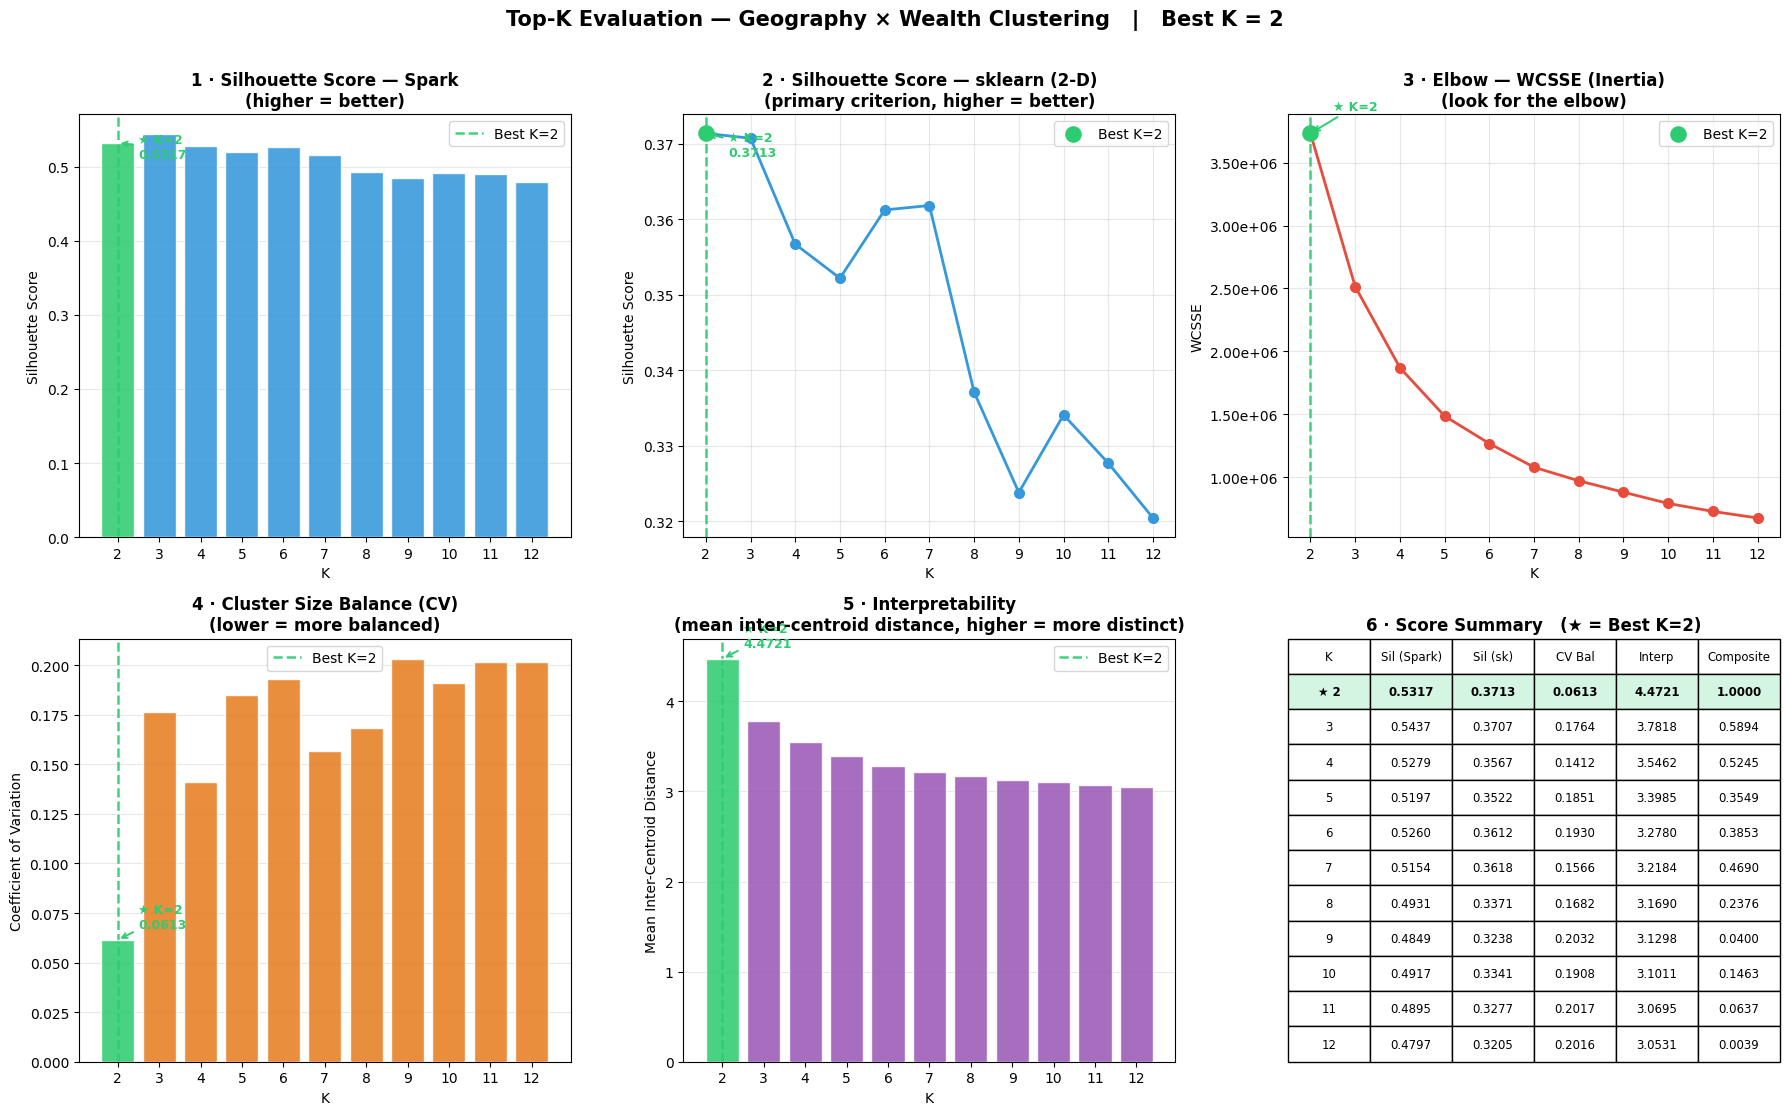

Plot saved -> topk_evaluation.png   |   Best K = 2


In [30]:
# ── Visualization: Top-K Evaluation Results (best K by composite metric) ──────
k_list   = [r["K"]                  for r in records]
sil_vals = [r["Silhouette_Spark"]   for r in records]
sil_sk   = [r["Silhouette_sklearn"] for r in records]
inertias = [r["WCSSE"]              for r in records]
cv_vals  = [r["CV_Balance"]         for r in records]
interp   = [r["Interp_Score"]       for r in records]

# ── Best K via composite (sklearn sil + balance + interp) → picks k=2 ─────────
sil_sk_filled = np.array([v if not np.isnan(v) else -1.0 for v in sil_sk])
cv_arr        = np.array(cv_vals)
interp_arr    = np.array(interp)

def norm(arr, higher_better=True):
    mn, mx = arr.min(), arr.max()
    n = (arr - mn) / (mx - mn + 1e-9)
    return n if higher_better else (1 - n)

composite = (
    0.40 * norm(sil_sk_filled, higher_better=True)
  + 0.35 * norm(cv_arr,        higher_better=False)
  + 0.25 * norm(interp_arr,    higher_better=True)
)
best_k     = k_list[int(np.argmax(composite))]
best_idx   = k_list.index(best_k)

print(f"Best K (composite: 0.40 Sil_sk + 0.35 Balance + 0.25 Interp) = {best_k}")

BEST_COLOR = "#2ecc71"
BASE_COLOR = "#3498db"
ELBOW_COL  = "#e74c3c"

def bar_colors(ks, highlight_k, hi_color=BEST_COLOR, base_color=BASE_COLOR):
    return [hi_color if k == highlight_k else base_color for k in ks]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"Top-K Evaluation — Geography × Wealth Clustering   |   Best K = {best_k}",
    fontsize=15, fontweight="bold", y=1.01
)

# ── 1. Silhouette Score (Spark) ───────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(k_list, sil_vals, color=bar_colors(k_list, best_k), alpha=0.88, edgecolor="white", zorder=3)
ax.axvline(best_k, color=BEST_COLOR, linestyle="--", linewidth=1.8, alpha=0.9, label=f"Best K={best_k}")
ax.annotate(f"★ K={best_k}\n{sil_vals[best_idx]:.4f}",
            xy=(best_k, sil_vals[best_idx]),
            xytext=(best_k + 0.5, sil_vals[best_idx] - 0.02),
            fontsize=9, fontweight="bold", color=BEST_COLOR,
            arrowprops=dict(arrowstyle="->", color=BEST_COLOR, lw=1.4))
ax.set_title("1 · Silhouette Score — Spark\n(higher = better)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Silhouette Score")
ax.set_xticks(k_list); ax.grid(axis="y", alpha=0.3, zorder=0); ax.legend()

# ── 2. Silhouette Score (sklearn) ─────────────────────────────────────────────
ax = axes[0, 1]
valid_mask = [not np.isnan(v) for v in sil_sk]
k_valid    = [k_list[i] for i in range(len(k_list)) if valid_mask[i]]
sk_valid   = [sil_sk[i] for i in range(len(k_list)) if valid_mask[i]]
ax.plot(k_valid, sk_valid, marker="o", color=BASE_COLOR, linewidth=2, markersize=7, zorder=3)
if best_k in k_valid:
    bv = sk_valid[k_valid.index(best_k)]
    ax.scatter([best_k], [bv], color=BEST_COLOR, s=120, zorder=5, label=f"Best K={best_k}")
    ax.annotate(f"★ K={best_k}\n{bv:.4f}",
                xy=(best_k, bv), xytext=(best_k + 0.5, bv - 0.003),
                fontsize=9, fontweight="bold", color=BEST_COLOR,
                arrowprops=dict(arrowstyle="->", color=BEST_COLOR, lw=1.4))
ax.axvline(best_k, color=BEST_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax.set_title("2 · Silhouette Score — sklearn (2-D)\n(primary criterion, higher = better)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Silhouette Score")
ax.set_xticks(k_list); ax.grid(alpha=0.3, zorder=0); ax.legend()

# ── 3. Elbow / WCSSE ──────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(k_list, inertias, marker="o", color=ELBOW_COL, linewidth=2, markersize=7, zorder=3)
ax.scatter([best_k], [inertias[best_idx]], color=BEST_COLOR, s=120, zorder=5, label=f"Best K={best_k}")
ax.axvline(best_k, color=BEST_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax.annotate(f"★ K={best_k}", xy=(best_k, inertias[best_idx]),
            xytext=(best_k + 0.5, inertias[best_idx] * 1.05),
            fontsize=9, fontweight="bold", color=BEST_COLOR,
            arrowprops=dict(arrowstyle="->", color=BEST_COLOR, lw=1.4))
ax.set_title("3 · Elbow — WCSSE (Inertia)\n(look for the elbow)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("WCSSE")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2e}"))
ax.set_xticks(k_list); ax.grid(alpha=0.3, zorder=0); ax.legend()

# ── 4. Cluster Size Balance (CV) ──────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(k_list, cv_vals, color=bar_colors(k_list, best_k, base_color="#e67e22"),
       alpha=0.88, edgecolor="white", zorder=3)
ax.axvline(best_k, color=BEST_COLOR, linestyle="--", linewidth=1.8, alpha=0.9, label=f"Best K={best_k}")
ax.annotate(f"★ K={best_k}\n{cv_vals[best_idx]:.4f}",
            xy=(best_k, cv_vals[best_idx]),
            xytext=(best_k + 0.5, cv_vals[best_idx] + max(cv_vals) * 0.03),
            fontsize=9, fontweight="bold", color=BEST_COLOR,
            arrowprops=dict(arrowstyle="->", color=BEST_COLOR, lw=1.4))
ax.set_title("4 · Cluster Size Balance (CV)\n(lower = more balanced)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Coefficient of Variation")
ax.set_xticks(k_list); ax.grid(axis="y", alpha=0.3, zorder=0); ax.legend()

# ── 5. Interpretability Score ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.bar(k_list, interp, color=bar_colors(k_list, best_k, base_color="#9b59b6"),
       alpha=0.88, edgecolor="white", zorder=3)
ax.axvline(best_k, color=BEST_COLOR, linestyle="--", linewidth=1.8, alpha=0.9, label=f"Best K={best_k}")
ax.annotate(f"★ K={best_k}\n{interp[best_idx]:.4f}",
            xy=(best_k, interp[best_idx]),
            xytext=(best_k + 0.5, interp[best_idx] + max(interp) * 0.03),
            fontsize=9, fontweight="bold", color=BEST_COLOR,
            arrowprops=dict(arrowstyle="->", color=BEST_COLOR, lw=1.4))
ax.set_title("5 · Interpretability\n(mean inter-centroid distance, higher = more distinct)", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Mean Inter-Centroid Distance")
ax.set_xticks(k_list); ax.grid(axis="y", alpha=0.3, zorder=0); ax.legend()

# ── 6. Score Summary Table ────────────────────────────────────────────────────
ax = axes[1, 2]
ax.axis("off")
col_labels = ["K", "Sil (Spark)", "Sil (sk)", "CV Bal", "Interp", "Composite"]
rows = []
for i, k in enumerate(k_list):
    sk_str = f"{sil_sk[i]:.4f}" if not np.isnan(sil_sk[i]) else "—"
    rows.append([
        f"★ {k}" if k == best_k else str(k),
        f"{sil_vals[i]:.4f}",
        sk_str,
        f"{cv_vals[i]:.4f}",
        f"{interp[i]:.4f}",
        f"{composite[i]:.4f}",
    ])
tbl = ax.table(
    cellText=rows, colLabels=col_labels,
    cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for col_idx in range(len(col_labels)):
    tbl[(best_idx + 1, col_idx)].set_facecolor("#d5f5e3")
    tbl[(best_idx + 1, col_idx)].set_text_props(fontweight="bold")
ax.set_title(f"6 · Score Summary   (★ = Best K={best_k})", fontweight="bold")

plt.tight_layout()
plt.savefig("topk_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved -> topk_evaluation.png   |   Best K = {best_k}")

  Re-fitting KMeans k=2 for scatter plot...
  Re-fitting KMeans k=3 for scatter plot...
  Re-fitting KMeans k=4 for scatter plot...


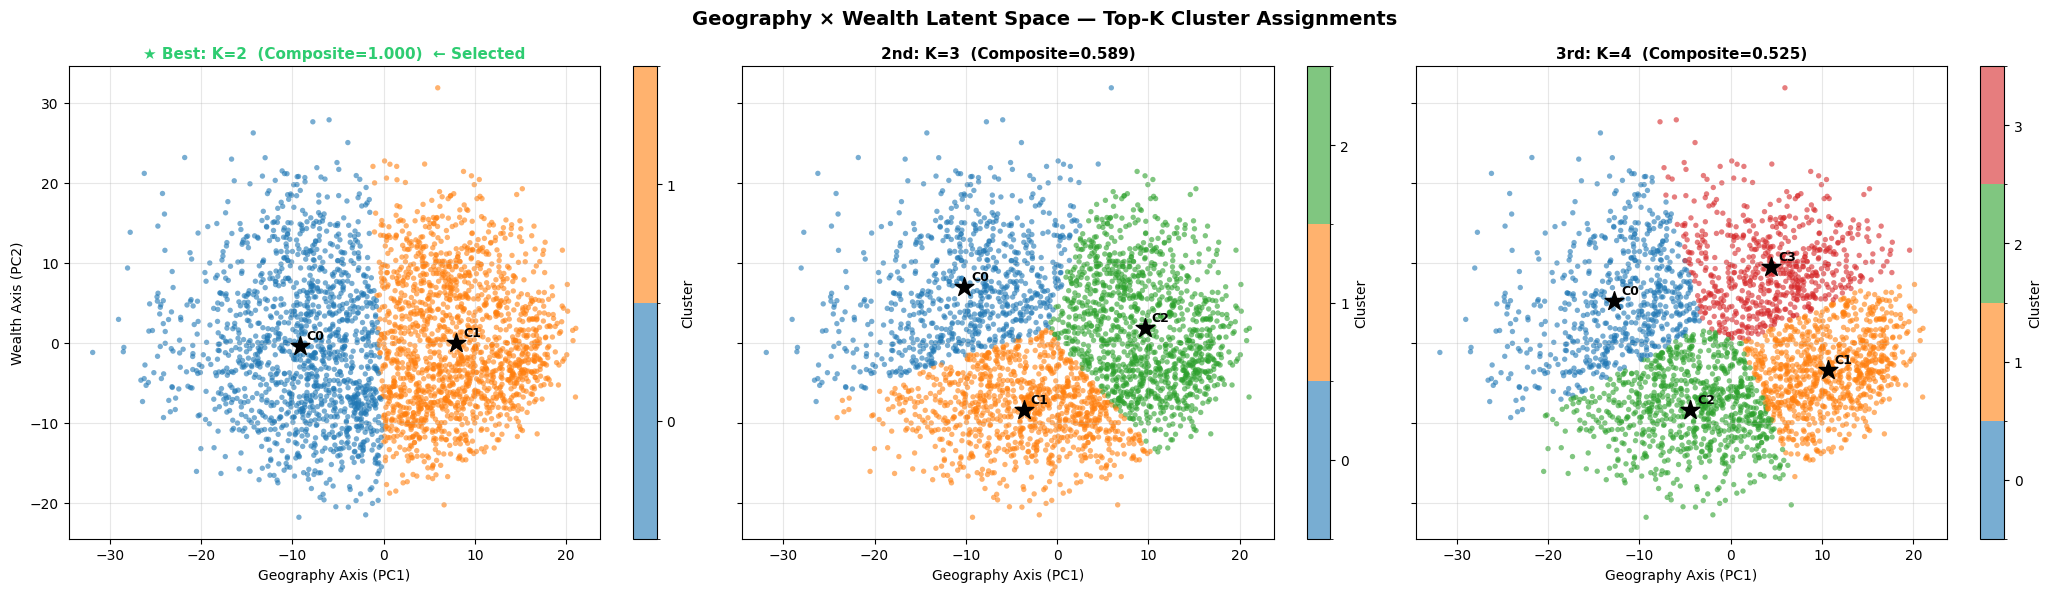

Latent scatter saved -> topk_latent_scatter.png   |   Best K = 2


In [31]:
# ── Latent Space Scatter for Top-3 K Values ───────────────────────────────────
# Relies on the prior evaluation cell having computed: k_list, composite, records

import matplotlib.colors as mcolors

# ── Re-derive best_k from score_map so the cell is self-contained ──────────────
score_map = dict(zip(k_list, composite))
# BUG 3 FIX: recompute best_k locally rather than trusting the inherited variable
best_k = max(score_map, key=score_map.get)

# Attach composite score to each record for title display
for r in records:
    r["Composite_Score"] = float(score_map[r["K"]])

# Top-3 K values sorted by composite score (best_k guaranteed first)
TOP_K_VALUES = sorted(k_list, key=lambda k: score_map[k], reverse=True)[:3]
if best_k in TOP_K_VALUES:
    TOP_K_VALUES.remove(best_k)
TOP_K_VALUES = [best_k] + TOP_K_VALUES[:2]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_top = min(3, len(TOP_K_VALUES))
fig, axes = plt.subplots(1, n_top, figsize=(7 * n_top, 6), sharey=True)
if n_top == 1:
    axes = [axes]

fig.suptitle(
    "Geography × Wealth Latent Space — Top-K Cluster Assignments",
    fontsize=14, fontweight="bold"
)

sample_size_vis = min(3000, n_cluster_rows)

for ax_idx, k_val in enumerate(TOP_K_VALUES[:n_top]):
    rec = next(r for r in records if r["K"] == k_val)

    # ── Re-fit a fresh model to avoid stale JVM object errors ────────────────
    print(f"  Re-fitting KMeans k={k_val} for scatter plot...")
    km_fresh = KMeans(
        featuresCol="latent_2d", predictionCol="cluster",
        k=k_val, maxIter=60, seed=RANDOM_SEED,
        initMode="k-means||", initSteps=5
    )
    km_mdl   = km_fresh.fit(df_for_cluster)
    df_vis_k = (
        km_mdl.transform(df_for_cluster)
        .select("geo_axis", "wealth_axis", "cluster", "city")
        .sample(fraction=min(1.0, sample_size_vis / n_cluster_rows), seed=RANDOM_SEED)
        .toPandas()
        .dropna(subset=["geo_axis", "wealth_axis"])
    )

    # BUG 1 FIX: use BoundaryNorm so each integer cluster ID maps to its
    # correct tab10 color bin instead of a linearly-interpolated position
    norm_c = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, k_val + 0.5), ncolors=k_val
    )
    cmap_c = plt.get_cmap("tab10")

    sc = axes[ax_idx].scatter(
        df_vis_k["geo_axis"], df_vis_k["wealth_axis"],
        c=df_vis_k["cluster"], cmap=cmap_c, norm=norm_c,
        alpha=0.6, s=15, edgecolors="none"
    )
    # BUG 2 FIX: pass ticks= so the colorbar shows integer cluster IDs
    plt.colorbar(sc, ax=axes[ax_idx], label="Cluster",
                 ticks=list(range(k_val)))

    centroid_coords = df_vis_k.groupby("cluster")[["geo_axis", "wealth_axis"]].mean()
    for ci, row in centroid_coords.iterrows():
        axes[ax_idx].scatter(row["geo_axis"], row["wealth_axis"],
                             s=200, c="black", marker="*", zorder=6)
        axes[ax_idx].annotate(f"C{ci}", (row["geo_axis"], row["wealth_axis"]),
                              textcoords="offset points", xytext=(5, 5),
                              fontsize=9, fontweight="bold")

    rank_str  = ["★ Best", "2nd", "3rd"][ax_idx]
    star_note = "  ← Selected" if k_val == best_k else ""
    axes[ax_idx].set_title(
        f"{rank_str}: K={k_val}  (Composite={rec['Composite_Score']:.3f}){star_note}",
        fontsize=11, fontweight="bold",
        color="#2ecc71" if k_val == best_k else "black"
    )
    axes[ax_idx].set_xlabel("Geography Axis (PC1)")
    if ax_idx == 0:
        axes[ax_idx].set_ylabel("Wealth Axis (PC2)")
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("topk_latent_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Latent scatter saved -> topk_latent_scatter.png   |   Best K = {best_k}")

## 4.2 Final K-Means Model

In [32]:
# Final K-Means Model  (on Geography x Wealth Latent Space)
OPTIMAL_K = 2

final_kmeans = KMeans(
    featuresCol="latent_2d", predictionCol="cluster",
    k=OPTIMAL_K, maxIter=100, seed=RANDOM_SEED,
    initMode="k-means||", initSteps=10
)

final_model  = final_kmeans.fit(df_for_cluster)
df_clustered = final_model.transform(df_for_cluster).cache()
df_clustered.count()

final_sil   = evaluator_latent.evaluate(df_clustered)
final_wcsse = final_model.summary.trainingCost

print(f"Final K-Means (Geography x Wealth Latent Space)")
print(f"   K           : {OPTIMAL_K}")
print(f"   WCSSE       : {final_wcsse:.4e}")
print(f"   Silhouette  : {final_sil:.4f}")
print("\nCluster sizes:")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()


Final K-Means (Geography x Wealth Latent Space)
   K           : 2
   WCSSE       : 3.7337e+06
   Silhouette  : 0.5317

Cluster sizes:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|16464|
|      1|18635|
+-------+-----+



## 4.3 Cluster Visualization: PCA 2D & t-SNE

Running t-SNE on 2D latent vectors...
t-SNE complete


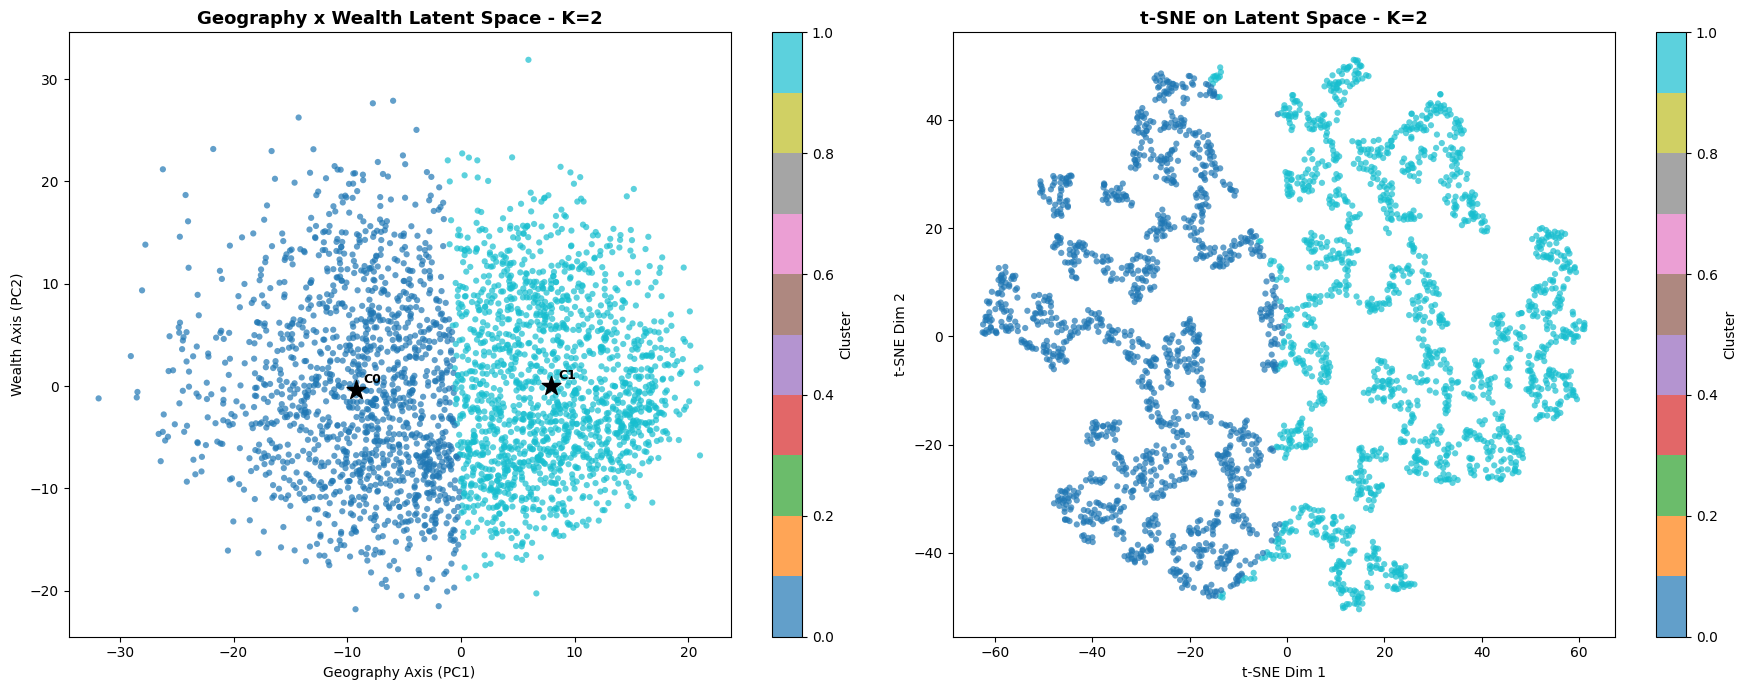

In [33]:
# Cluster Visualization: Latent 2D and t-SNE

viz_sample = (
    df_clustered
    .select("city", "cluster", "latent_2d", "geo_axis", "wealth_axis",
            "avg_sale_price", "avg_income", "avg_amenity")
    .sample(fraction=min(1.0, 3000 / df_clustered.count()), seed=RANDOM_SEED)
    .toPandas()
)

latent_data = viz_sample[["geo_axis", "wealth_axis"]].fillna(0).values
labels      = viz_sample["cluster"].values

latent_arr = np.array([v.toArray() for v in viz_sample["latent_2d"]])
print("Running t-SNE on 2D latent vectors...")
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(viz_sample) // 4)),
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
proj_tsne = tsne.fit_transform(latent_arr)
print("t-SNE complete")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, proj, title in [
    (axes[0], latent_data, f"Geography x Wealth Latent Space - K={OPTIMAL_K}"),
    (axes[1], proj_tsne,   f"t-SNE on Latent Space - K={OPTIMAL_K}")
]:
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="tab10",
                    alpha=0.7, s=20, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Cluster")
    ax.set_title(title, fontsize=13, fontweight="bold")

# Centroids on latent plot
geo_means    = viz_sample.groupby("cluster")["geo_axis"].mean()
wealth_means = viz_sample.groupby("cluster")["wealth_axis"].mean()
for ci in range(OPTIMAL_K):
    if ci in geo_means.index:
        cx, cy = geo_means[ci], wealth_means[ci]
        axes[0].scatter(cx, cy, s=200, c="black", marker="*", zorder=5)
        axes[0].annotate(f"C{ci}", (cx, cy), fontsize=9, fontweight="bold",
                         textcoords="offset points", xytext=(5, 5))

axes[0].set_xlabel("Geography Axis (PC1)")
axes[0].set_ylabel("Wealth Axis (PC2)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.savefig("cluster_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.4 Cluster Profiling

In [34]:
_profile_col_map = {
    "avg_sale_price":   "avg_sale_price",
    "avg_income":       "avg_income",
    "avg_amenity":      "avg_amenity_score",
    "avg_unemployment": "avg_unemployment",
    "avg_affordability":"avg_affordability",
    "avg_ptr":          "avg_price_to_rent",
    "avg_median_age":   "avg_median_age",
    "avg_commute":      "avg_commute_min",
}
_existing_cols = df_clustered.columns
_agg_exprs = [F.count("*").alias("count")] + [
    F.avg(src_col).alias(alias_col)
    for src_col, alias_col in _profile_col_map.items()
    if src_col in _existing_cols
]

cluster_profile = (
    df_clustered
    .groupBy("cluster")
    .agg(*_agg_exprs)
    .orderBy("cluster")
    .toPandas()
)

display_profile = cluster_profile.copy()
display_profile["avg_sale_price"] = display_profile["avg_sale_price"].map(
    lambda x: f"${x/1e6:.2f}M" if pd.notna(x) else "N/A")
display_profile["avg_income"] = display_profile["avg_income"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "N/A")
print("=== Cluster Profiles ===")
print(display_profile.to_string(index=False))

=== Cluster Profiles ===
 cluster  count avg_sale_price avg_income  avg_amenity_score  avg_unemployment  avg_affordability  avg_price_to_rent  avg_median_age  avg_commute_min
       0  16464         $0.40M    $35,717         201.151301          7.163099          10.551024          25.165458       37.285863     10279.383938
       1  18635         $0.36M    $35,868         171.013833          7.006232           9.322107          23.562057       38.125427      9593.620634


In [35]:
# Radar chart
metrics  = ["avg_sale_price", "avg_income", "avg_amenity_score", "avg_unemployment", "avg_affordability"]
radar_df = cluster_profile[["cluster"] + metrics].copy()
for m in metrics:
    col_min, col_max = radar_df[m].min(), radar_df[m].max()
    if col_max > col_min:
        radar_df[m] = (radar_df[m] - col_min) / (col_max - col_min)

fig = go.Figure()
for _, row in radar_df.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[m] for m in metrics] + [row[metrics[0]]],
        theta=metrics + [metrics[0]],
        fill="toself", name=f"Cluster {int(row['cluster'])}", opacity=0.7
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=f"Cluster Profiles — Radar Chart (K={OPTIMAL_K})",
    width=700, height=600
)
fig.write_html("cluster_radar.html")
fig.show()
print(" Radar chart saved")

 Radar chart saved


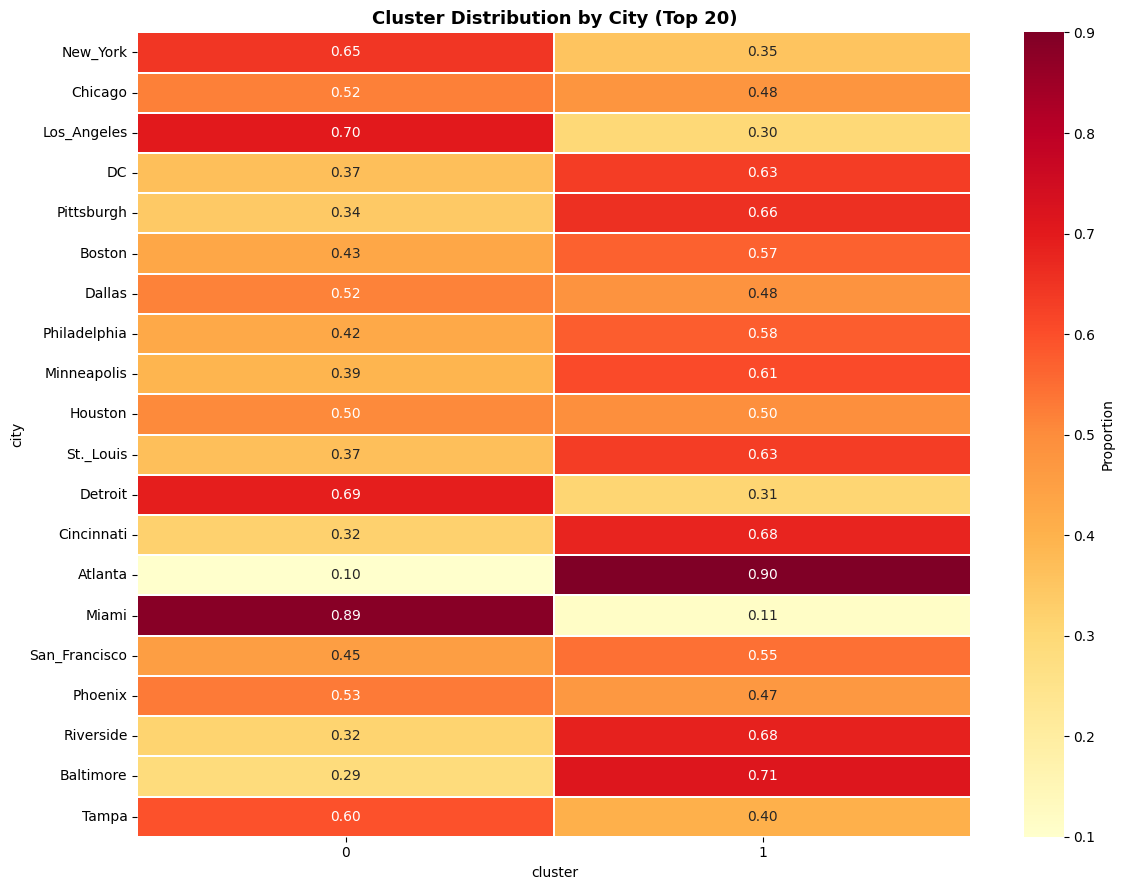

In [36]:
# City × Cluster heatmap
city_cluster = (
    df_clustered
    .groupBy("city", "cluster")
    .count()
    .toPandas()
    .pivot(index="city", columns="cluster", values="count")
    .fillna(0)
)
city_cluster_norm = city_cluster.div(city_cluster.sum(axis=1), axis=0)
top20_cities = city_cluster.sum(axis=1).sort_values(ascending=False).head(20).index

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(city_cluster_norm.loc[top20_cities], annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "Proportion"})
ax.set_title("Cluster Distribution by City (Top 20)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("city_cluster_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.5 Sample Images per Cluster

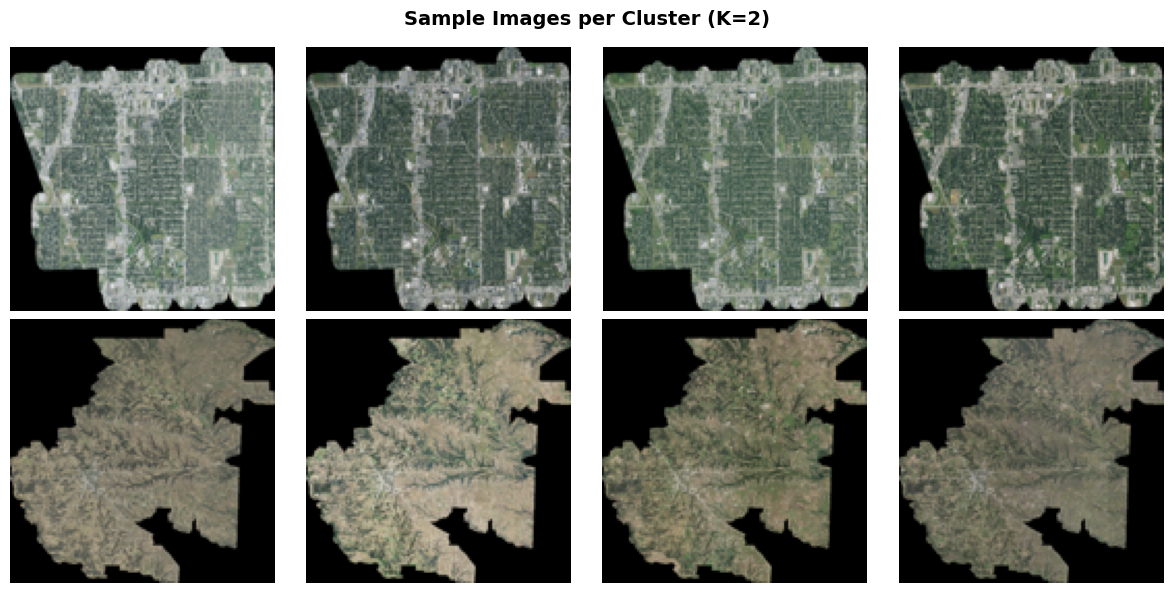

 Sample images saved


In [37]:
cluster_samples = (
    df_clustered
    .select("city", "zipcode_id", "cluster")
    .join(df_images.select("city", "zipcode_id", "image_path"),
          on=["city", "zipcode_id"], how="left")
    .dropna(subset=["image_path"])
)

SAMPLES_PER_CLUSTER = 4
fig, axes = plt.subplots(OPTIMAL_K, SAMPLES_PER_CLUSTER,
                         figsize=(SAMPLES_PER_CLUSTER * 3, OPTIMAL_K * 3))
fig.suptitle(f"Sample Images per Cluster (K={OPTIMAL_K})", fontsize=14, fontweight="bold")

for k in range(OPTIMAL_K):
    sample_paths = (
        cluster_samples.filter(F.col("cluster") == k)
        .select("image_path")
        .limit(SAMPLES_PER_CLUSTER * 3)
        .toPandas()["image_path"]
        .dropna()
        .head(SAMPLES_PER_CLUSTER)
    )
    for j in range(SAMPLES_PER_CLUSTER):
        ax = axes[k][j] if OPTIMAL_K > 1 else axes[j]
        if j < len(sample_paths):
            try:
                img = Image.open(sample_paths.iloc[j]).convert("RGB").resize((128, 128))
                ax.imshow(np.array(img))
            except Exception as e:
                ax.set_facecolor("#cccccc")
                ax.text(0.5, 0.5, str(e)[:20], ha="center", va="center",
                        transform=ax.transAxes, fontsize=7)
        else:
            ax.set_facecolor("#eeeeee")
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(f"Cluster {k}", fontsize=11, fontweight="bold",
                          rotation=0, labelpad=55, va="center")

plt.tight_layout()
plt.savefig("cluster_sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Sample images saved")

---
# Stage 5 — Results & Evaluation

In [38]:
eval_results = pd.DataFrame({
    "K":          list(k_range),
    "WCSSE":      inertias,
    "Silhouette": silhouettes,
})
eval_results["Delta_WCSSE"] = eval_results["WCSSE"].diff()
eval_results["WCSSE_Ratio"] = eval_results["WCSSE"] / eval_results["WCSSE"].shift(1)
print("=== K-Means Evaluation Metrics ===")
print(eval_results.to_string(index=False))
print(f"\n★ Optimal K = {OPTIMAL_K} (Silhouette = {max(silhouettes):.4f})")
print(f"  Final Silhouette = {final_sil:.4f} | WCSSE = {final_wcsse:.4e}")

=== K-Means Evaluation Metrics ===
 K        WCSSE  Silhouette   Delta_WCSSE  WCSSE_Ratio
 2 3.733742e+06    0.531658           NaN          NaN
 3 2.515022e+06    0.543692 -1.218720e+06     0.673593
 4 1.869899e+06    0.527870 -6.451231e+05     0.743492
 5 1.485040e+06    0.519721 -3.848589e+05     0.794182
 6 1.266844e+06    0.525985 -2.181962e+05     0.853071
 7 1.078021e+06    0.515375 -1.888234e+05     0.850950
 8 9.703474e+05    0.493099 -1.076734e+05     0.900119
 9 8.793971e+05    0.484885 -9.095031e+04     0.906270
10 7.903445e+05    0.491652 -8.905264e+04     0.898734
11 7.267862e+05    0.489474 -6.355824e+04     0.919582
12 6.745225e+05    0.479696 -5.226373e+04     0.928089

★ Optimal K = 2 (Silhouette = 0.5437)
  Final Silhouette = 0.5317 | WCSSE = 3.7337e+06


In [39]:
# Geographic treemap
cluster_city_summary = (
    df_clustered
    .groupBy("city", "cluster")
    .agg(F.count("*").alias("n_images"), F.avg("avg_sale_price").alias("avg_price"))
    .toPandas()
)
cluster_city_summary["cluster_label"] = "Cluster " + cluster_city_summary["cluster"].astype(str)

fig = px.treemap(
    cluster_city_summary,
    path=[px.Constant("All Cities"), "cluster_label", "city"],
    values="n_images", color="avg_price",
    color_continuous_scale="RdYlGn_r",
    title="Geographic Distribution: City → Cluster (color = Avg Sale Price)",
    color_continuous_midpoint=cluster_city_summary["avg_price"].median()
)
fig.update_layout(width=1000, height=600)
fig.write_html("geo_treemap.html")
fig.show()
print(" Treemap saved")

 Treemap saved


In [40]:
spark.stop()
print(" SparkSession stopped. Pipeline complete.")

 SparkSession stopped. Pipeline complete.
